# Contextual Analysis of Parental Concerns in Child–GenAI Interactions

This notebook implements a multi-part analysis testing whether parental concerns about
child–chatbot interactions are contextually dependent.

**Parts:**
- **Part 0:** Data loading, merging, and descriptive summary
- **Utility:** Export highlights to CSV for manual/LLM coding
- **Part 1:** Do parental concerns vary by context? (mixed-effects models)
- **Part 2:** Which contexts are most influential? (effect size ranking)
- **Part 3:** Does context shape concern type? (requires concern codes)
- **Part 4:** Scalability of response characteristic coding (requires human + LLM codes)
- **Part 5:** Realism invariance check

**Data hierarchy:** Parent (top) × Scenario (crossed) → Highlights (nested) → Codes (nested)

**Two analysis levels:**
- Session-level (primary): one row per parent × scenario moderation session
- Highlight-level (supplementary): one row per highlighted span with per-highlight sentiment

In [1]:
# ── Package Installation ─────────────────────────────────────────────────────
import subprocess, sys

def _ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

_ensure('pandas')
_ensure('numpy')
_ensure('scipy')
_ensure('statsmodels')
_ensure('matplotlib')
_ensure('seaborn')
_ensure('pingouin')
_ensure('patsy')
# Optional: uncomment for lasso interaction selection
# _ensure('scikit-learn', 'sklearn')
# Optional: uncomment for R-based mixed models (requires R + lme4)
# _ensure('pymer4')

In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import glob
import json
import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
from IPython.display import display, HTML
from scipy import stats
from scipy.stats import chi2, kruskal, mannwhitneyu
from statsmodels.formula.api import mixedlm, ols, logit
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='.*convergence.*')

sns.set_theme(style='whitegrid', context='notebook', palette='colorblind')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.figsize'] = (10, 6)

print('Imports loaded.')

Imports loaded.


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — Edit this cell to match your data export
# ══════════════════════════════════════════════════════════════════════════════

# ── Paths ──
# Resolve the repo root so paths work regardless of kernel working directory.
# The notebook lives at <REPO_ROOT>/stat_analysis/contextual_analysis.ipynb.
_NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
REPO_ROOT = os.path.abspath(os.path.join(_NOTEBOOK_DIR, '..'))
# Fallback: try common working-directory locations
if not os.path.isdir(os.path.join(REPO_ROOT, 'data-exports')):
    REPO_ROOT = os.path.abspath('.')
if not os.path.isdir(os.path.join(REPO_ROOT, 'data-exports')):
    REPO_ROOT = os.path.abspath('..')

# Auto-detect latest export folder under <REPO_ROOT>/data-exports/
_candidates = sorted(glob.glob(os.path.join(REPO_ROOT, 'data-exports', '*',
                                             'moderation_sessions_export_*.csv')))
if _candidates:
    DATA_DIR = os.path.dirname(_candidates[-1])
elif glob.glob('moderation_sessions_export_*.csv'):
    # Kernel CWD is already inside an export folder
    DATA_DIR = '.'
else:
    raise FileNotFoundError(
        'No moderation_sessions_export_*.csv found under '
        f'{os.path.join(REPO_ROOT, "data-exports")}. '
        'Run the export script first or set DATA_DIR manually.'
    )

_mod_files = sorted(glob.glob(os.path.join(DATA_DIR, 'moderation_sessions_export_*.csv')))
EXPORT_TIMESTAMP = _mod_files[-1].split('_export_')[1].replace('.csv', '')

SCENARIOS_JSON = os.path.join(REPO_ROOT, 'scenarios', 'pilot_scenarios.json')

# Optional coding files (may not exist yet)
RESPONSE_CHAR_CODES_FILE = None   # Path to CSV with response_characteristic codes
CONCERN_CODES_FILE = None         # Path to CSV with concern codes
LLM_RESPONSE_CHAR_CODES_FILE = None  # Path to LLM-coded response characteristics

# Output directory for exported results
OUTPUT_DIR = os.path.join(DATA_DIR, 'contextual_analysis_output')

# ── Mode ──
DEV_MODE = True  # True = skip Prolific PID filtering (for dev/test data)

# ── Analysis Parameters ──
ALPHA = 0.05
VALENCE_POSITIVE_THRESHOLD = 5   # sentiment >= this = positive
VALENCE_NEGATIVE_THRESHOLD = 3   # sentiment <= this = negative
# sentiment == 4 excluded from binary valence analysis

EQUIVALENCE_BOUND = 0.5          # TOST bound on 7-point scale
EQUIVALENCE_BOUND_OR = (0.8, 1.25)  # TOST bound for odds ratios
MIN_OBS_PER_CELL = 10            # minimum observations per interaction cell
MIN_OBS_FOR_MIXED = 50           # minimum rows for mixed-effects models
MIN_GROUPS_FOR_RE = 8            # minimum groups for random effect
MIN_CONCERN_CODE_PREVALENCE = 0.05  # minimum prevalence for per-code regression

# ── Column Name Mappings ──
COLS_SESSION = {
    'session_id': 'id',
    'parent_id': 'user_id',
    'scenario_id': 'scenario_id',
    'concern_level': 'concern_level',
    'concern_reason': 'concern_reason',
    'realism_level': 'realism_level',
    'initial_decision': 'initial_decision',
    'is_final_version': 'is_final_version',
    'scenario_prompt': 'scenario_prompt',
    'original_response': 'original_response',
    'highlighted_texts': 'highlighted_texts',
    'attempt_number': 'attempt_number',
    'version_number': 'version_number',
    'session_number': 'session_number',
    'prolific_pid': 'prolific_pid',
    'child_age': 'child_age',
    'child_gender': 'child_gender',
}

COLS_SCENARIO = {
    'scenario_id': 'scenario_id',
    'domain': 'domain',
    'subdomain': 'subdomain',
    'age_band': 'age_band',
    'gender_identity': 'gender_identity',
    'trait': 'trait',
    'trait_level': 'trait_level',
    'piaget_stage': 'piaget_stage',
    'intent': 'intent',
}

COLS_CONCERN_ITEM = {
    'concern_item_id': 'id',
    'session_id': 'session_id',
    'parent_id': 'user_id',
    'scenario_id': 'scenario_id',
    'text': 'text',
    'concern_level': 'concern_level',
    'linked_highlights': 'linked_highlights',
    'highlight_levels': 'highlight_levels',
    'prolific_pid': 'prolific_pid',
}

COLS_SELECTION = {
    'selection_id': 'id',
    'parent_id': 'user_id',
    'selected_text': 'selected_text',
    'scenario_id': 'scenario_id',
    'source': 'source',
    'start_offset': 'start_offset',
    'end_offset': 'end_offset',
    'assignment_id': 'assignment_id',
    'prolific_pid': 'prolific_pid',
}

EXIT_QUIZ_KEYS = {
    'parent_gender': 'parentGender',
    'parent_age_group': 'parentAge',
    'area_of_residency': 'areaOfResidency',
    'parent_education': 'parentEducation',
    'parent_ethnicity': 'parentEthnicity',
    'genai_familiarity': 'genaiFamiliarity',
    'genai_usage_frequency': 'genaiUsageFrequency',
    'parent_internet_use_frequency': 'parentInternetUseFrequency',
    'parenting_style': 'parentingStyle',
    'is_only_child': 'isOnlyChild',
    'child_has_ai_use': 'childHasAIUse',
    'child_ai_use_contexts': 'childAIUseContexts',
    'parent_llm_monitoring_level': 'parentLLMMonitoringLevel',
}

PARENTING_STYLE_MAP = {
    'A': 'authoritative',
    'B': 'authoritarian',
    'C': 'permissive',
    'D': 'uninvolved',
}

REFERENCE_LEVELS = {
    'domain': 'Casual Knowledge Domain',
    'age_band': '9-12',
    'sensitivity_level': 'available',
    'relationship_frame': 'tool',
    'space_type': 'shared_family_space',
    'breakdown_expected': 'no',
    'trait_level': 'low',
    'gender_identity': 'boy',
}

SCENARIO_FACTORS = [
    'age_band', 'domain', 'sensitivity_level', 'relationship_frame',
    'space_type', 'breakdown_expected', 'trait', 'trait_level', 'gender_identity',
]

PARENT_COVARIATES = [
    'parent_gender', 'parent_age_group', 'parent_education',
    'genai_familiarity', 'genai_usage_frequency',
]

print(f'Repo root: {REPO_ROOT}')
print(f'Data directory: {DATA_DIR}')
print(f'Export timestamp: {EXPORT_TIMESTAMP}')
print(f'Scenarios JSON: {SCENARIOS_JSON}')
print(f'DEV_MODE: {DEV_MODE}')

Repo root: /Users/johndriscoll/ParentalControl/DSL-kidsgpt-open-webui
Data directory: /Users/johndriscoll/ParentalControl/DSL-kidsgpt-open-webui/data-exports/20260402_141950_PILOT6
Export timestamp: 20260402_141950
Scenarios JSON: /Users/johndriscoll/ParentalControl/DSL-kidsgpt-open-webui/scenarios/pilot_scenarios.json
DEV_MODE: True


In [4]:
# ── Helper Functions ──────────────────────────────────────────────────────────

def parse_safety_notes(notes_str):
    """Extract structured fields from a scenario's safety_notes string.
    
    Format: 'description; space_type:X; breakdown_expected:Y; relationship_frame:Z; sensitivity_level:W'
    """
    result = {
        'sensitivity_level': None,
        'relationship_frame': None,
        'space_type': None,
        'breakdown_expected': None,
    }
    if not notes_str or pd.isna(notes_str):
        return result
    for field in result:
        m = re.search(rf'{field}:(\w+)', str(notes_str))
        if m:
            result[field] = m.group(1)
    return result


def parse_exit_answers(answers_raw):
    """Parse JSON answers blob from exit quiz into a flat dict."""
    if pd.isna(answers_raw) or not str(answers_raw).strip():
        return {}
    try:
        ans = json.loads(answers_raw) if isinstance(answers_raw, str) else answers_raw
    except (json.JSONDecodeError, TypeError):
        return {}
    flat = {}
    for concept_key, json_key in EXIT_QUIZ_KEYS.items():
        val = ans.get(json_key, None)
        # Convert lists to semicolon-separated strings for categorical use
        if isinstance(val, list):
            val = ';'.join(str(v) for v in val) if val else None
        flat[concept_key] = val
    return flat


def parse_highlights_json(raw):
    """Parse highlighted_texts from CSV (JSON string, list, or None) to list."""
    if isinstance(raw, list):
        return raw
    if pd.isna(raw):
        return []
    s = str(raw).strip()
    if not s or s == '[]':
        return []
    try:
        parsed = json.loads(s)
        return parsed if isinstance(parsed, list) else [parsed]
    except Exception:
        return [s]


def extract_child_age_numeric(age_str):
    """Extract numeric age from strings like '12 years old'."""
    if pd.isna(age_str):
        return np.nan
    m = re.search(r'(\d+)', str(age_str))
    return int(m.group(1)) if m else np.nan


def safe_json_loads(raw):
    """Safely parse a JSON string, returning {} on failure."""
    if pd.isna(raw) or not str(raw).strip():
        return {}
    try:
        return json.loads(raw) if isinstance(raw, str) else raw
    except (json.JSONDecodeError, TypeError):
        return {}


def power_check(df, parent_col='parent_id', scenario_col='scenario_id'):
    """Check whether data is sufficient for mixed-effects models."""
    n_obs = len(df)
    n_parents = df[parent_col].nunique()
    n_scenarios = df[scenario_col].nunique()
    
    can_mixed = n_obs >= MIN_OBS_FOR_MIXED and n_parents >= MIN_GROUPS_FOR_RE
    can_scenario_re = n_scenarios >= MIN_GROUPS_FOR_RE
    
    print(f'Observations: {n_obs} (need \u2265{MIN_OBS_FOR_MIXED} for mixed models)')
    print(f'Parents: {n_parents} (need \u2265{MIN_GROUPS_FOR_RE} for random effect)')
    print(f'Scenarios: {n_scenarios} (need \u2265{MIN_GROUPS_FOR_RE} for random effect)')
    
    if can_mixed:
        if can_scenario_re:
            strategy = 'mixed_crossed'
            print('\u2714 Sufficient for mixed model with crossed random effects.')
        else:
            strategy = 'mixed_parent_only'
            print('\u2714 Sufficient for mixed model with parent random intercept only.')
    elif n_parents >= 3:
        strategy = 'ols_clustered'
        print('\u26a0 Insufficient for mixed models. Using OLS with clustered SEs.')
    else:
        strategy = 'descriptive_only'
        print('\u26a0 Too few observations. Descriptive + nonparametric tests only.')
    
    return strategy, n_obs, n_parents, n_scenarios


def fit_mixed_or_fallback(formula, data, groups_col, vc_formula=None, family='gaussian'):
    """Attempt mixed-effects model; fall back to OLS with clustered SEs on failure."""
    result = {'model_type': None, 'model': None, 'summary': None, 'converged': False}
    
    # Try mixed-effects model
    try:
        if family == 'gaussian':
            md = mixedlm(formula, data, groups=data[groups_col],
                         vc_formula=vc_formula)
            fit = md.fit(reml=True, maxiter=200)
        else:
            # For binary outcome, use GEE as approximation
            from statsmodels.genmod.generalized_estimating_equations import GEE
            from statsmodels.genmod.families import Binomial
            md = GEE.from_formula(formula, groups=groups_col, data=data,
                                  family=Binomial())
            fit = md.fit(maxiter=200)
        
        result['model_type'] = 'mixed' if family == 'gaussian' else 'gee'
        result['model'] = fit
        result['converged'] = True
        result['summary'] = fit.summary()
        return result
    except Exception as e:
        print(f'Mixed model failed: {e}')
        print('Falling back to OLS with clustered standard errors.')
    
    # Fallback: OLS with clustered SEs
    try:
        if family == 'gaussian':
            fit = ols(formula, data=data).fit(
                cov_type='cluster', cov_kwds={'groups': data[groups_col]}
            )
        else:
            fit = logit(formula, data=data).fit(
                cov_type='cluster', cov_kwds={'groups': data[groups_col]},
                disp=False
            )
        result['model_type'] = 'ols_clustered' if family == 'gaussian' else 'logit_clustered'
        result['model'] = fit
        result['converged'] = True
        result['summary'] = fit.summary()
    except Exception as e:
        print(f'OLS fallback also failed: {e}')
    
    return result


print('Helper functions defined.')

Helper functions defined.


---
## Part 0: Data Loading, Merging, and Descriptive Summary

In [5]:
# ── Cell 0b: Load All Data Files ──────────────────────────────────────────────

def _load(prefix):
    path = os.path.join(DATA_DIR, f'{prefix}_{EXPORT_TIMESTAMP}.csv')
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f'  {prefix}: {len(df)} rows, {len(df.columns)} cols')
        return df
    else:
        print(f'  {prefix}: FILE NOT FOUND at {path}')
        return pd.DataFrame()

print(f'Loading from: {DATA_DIR} (timestamp: {EXPORT_TIMESTAMP})')

moderation_df = _load('moderation_sessions_export')
concern_items_df = _load('concern_items_export')
selections_df = _load('selections_export')
scenarios_df = _load('scenarios_export')
exit_quiz_df = _load('exit_quiz_responses_export')
child_profiles_df = _load('child_profiles_export')
users_df = _load('users_export')

# Load scenario JSON for safety_notes metadata
_json_path = SCENARIOS_JSON
if os.path.exists(_json_path):
    with open(_json_path) as f:
        scenarios_json = json.load(f)
    print(f'  scenarios JSON: {len(scenarios_json)} scenarios')
else:
    print(f'  scenarios JSON: NOT FOUND at {_json_path}')
    scenarios_json = []

# Load optional coding files
response_char_codes_df = pd.DataFrame()
concern_codes_df = pd.DataFrame()
llm_response_char_codes_df = pd.DataFrame()

if RESPONSE_CHAR_CODES_FILE and os.path.exists(RESPONSE_CHAR_CODES_FILE):
    response_char_codes_df = pd.read_csv(RESPONSE_CHAR_CODES_FILE)
    print(f'  response char codes: {len(response_char_codes_df)} rows')

if CONCERN_CODES_FILE and os.path.exists(CONCERN_CODES_FILE):
    concern_codes_df = pd.read_csv(CONCERN_CODES_FILE)
    print(f'  concern codes: {len(concern_codes_df)} rows')

if LLM_RESPONSE_CHAR_CODES_FILE and os.path.exists(LLM_RESPONSE_CHAR_CODES_FILE):
    llm_response_char_codes_df = pd.read_csv(LLM_RESPONSE_CHAR_CODES_FILE)
    print(f'  LLM response char codes: {len(llm_response_char_codes_df)} rows')

Loading from: /Users/johndriscoll/ParentalControl/DSL-kidsgpt-open-webui/data-exports/20260402_141950_PILOT6 (timestamp: 20260402_141950)
  moderation_sessions_export: 24 rows, 38 cols
  concern_items_export: 46 rows, 22 cols
  selections_export: 58 rows, 20 cols
  scenarios_export: 50 rows, 21 cols
  exit_quiz_responses_export: 6 rows, 17 cols
  child_profiles_export: 6 rows, 22 cols
  users_export: 6 rows, 17 cols
  scenarios JSON: 50 scenarios


In [6]:
# ── Cell 0c: Parse & Enrich Scenario Metadata ────────────────────────────────
# Extract sensitivity_level, relationship_frame, space_type, breakdown_expected
# from the safety_notes field in pilot_scenarios.json.
# Match to scenario_ids via prompt text.

if scenarios_json:
    # Build prompt → safety_notes lookup from JSON
    json_prompt_lookup = {}
    for s in scenarios_json:
        prompt = s.get('child_prompt', '')
        parsed = parse_safety_notes(s.get('safety_notes', ''))
        parsed['prompt_text'] = prompt
        parsed['response_text'] = s.get('model_response', '')
        parsed['json_domain'] = s.get('domain', '')
        parsed['json_age_band'] = s.get('age_band', '')
        json_prompt_lookup[prompt] = parsed

    # Build scenario_id → prompt mapping from moderation sessions
    sid_prompt_map = (
        moderation_df[['scenario_id', 'scenario_prompt']]
        .dropna(subset=['scenario_id', 'scenario_prompt'])
        .drop_duplicates('scenario_id')
        .set_index('scenario_id')['scenario_prompt']
        .to_dict()
    )

    # Match scenario_id → JSON metadata via prompt text
    enrichment_rows = []
    matched, unmatched = 0, 0
    for sid, prompt in sid_prompt_map.items():
        meta = json_prompt_lookup.get(prompt)
        if meta is None:
            # Try fuzzy: strip whitespace
            prompt_stripped = prompt.strip()
            for jp, jm in json_prompt_lookup.items():
                if jp.strip() == prompt_stripped:
                    meta = jm
                    break
        if meta:
            enrichment_rows.append({'scenario_id': sid, **meta})
            matched += 1
        else:
            unmatched += 1

    scenario_enrichment_df = pd.DataFrame(enrichment_rows)
    print(f'Scenario enrichment: {matched} matched, {unmatched} unmatched of {len(sid_prompt_map)} scenario IDs in data.')

    # Also enrich ALL 50 scenarios by matching from scenarios_df prompt_text (via moderation)
    # For scenarios not yet seen in moderation, we can still build the map
    # by matching scenarios_df metadata (domain, age_band) to JSON
    if not scenario_enrichment_df.empty:
        # Merge enrichment onto scenarios_df
        scenarios_enriched_df = scenarios_df.merge(
            scenario_enrichment_df[['scenario_id', 'sensitivity_level', 'relationship_frame',
                                    'space_type', 'breakdown_expected', 'prompt_text', 'response_text']],
            on='scenario_id', how='left'
        )
        _n_enriched = scenarios_enriched_df['sensitivity_level'].notna().sum()
        print(f'Scenarios with full metadata: {_n_enriched}/{len(scenarios_enriched_df)}')
    else:
        scenarios_enriched_df = scenarios_df.copy()
        print('WARNING: No scenario enrichment could be performed.')
else:
    scenarios_enriched_df = scenarios_df.copy()
    print('WARNING: No scenario JSON available. Missing: sensitivity_level, relationship_frame, space_type, breakdown_expected.')

display(scenarios_enriched_df[['scenario_id', 'domain', 'age_band', 'sensitivity_level',
                                'relationship_frame', 'space_type', 'breakdown_expected']].head(10))

Scenario enrichment: 21 matched, 0 unmatched of 21 scenario IDs in data.
Scenarios with full metadata: 21/50


,scenario_id,domain,age_band,sensitivity_level,relationship_frame,space_type,breakdown_expected
0,scenario_72bd33b0-62db-4480-8034-3e1c88afd596,Academic Domain,13-15,NaN,NaN,NaN,NaN
1,scenario_82fc7897-5ff7-422d-a2b0-45fa631acf38,Relationship Domain,16-18,sensitive,tool,private_space,no
2,scenario_9066bf8c-15f6-4c3e-951b-63e29008d892,Casual Knowledge Domain,13-15,NaN,NaN,NaN,NaN
3,scenario_90d12d1a-bfc2-47f1-9394-8a5de009cb3f,Casual Knowledge Domain,9-12,NaN,NaN,NaN,NaN
4,scenario_9de44bba-bcf2-4f71-87c3-7ecbec2dea5f,Academic Domain,16-18,NaN,NaN,NaN,NaN
5,scenario_a0eb1914-709b-4e8b-8e53-2e5d5f4ff35b,Relationship Domain,16-18,NaN,NaN,NaN,NaN
6,scenario_b1461c77-2ae5-442b-8620-be9754a715e6,Casual Knowledge Domain,6-8,NaN,NaN,NaN,NaN
7,scenario_e68cf40a-e8a0-4972-900a-8705b2dd416b,Casual Knowledge Domain,6-8,NaN,NaN,NaN,NaN
8,scenario_fbbc6059-c59c-4886-ae95-ff47408e2f6b,Casual Knowledge Domain,9-12,sensitive,companion,shared_family_space,no
9,scenario_1f6f88d3-74f9-47c0-b1f2-aed9d8318552,Academic Domain,9-12,NaN,NaN,NaN,NaN


In [7]:
# ── Cell 0d: Parse Exit Quiz JSON → Flat Parent Covariates ─────────────────────

if not exit_quiz_df.empty and 'answers' in exit_quiz_df.columns:
    # Keep only current responses per user
    _eq = exit_quiz_df.copy()
    if 'is_current' in _eq.columns:
        _eq_current = _eq[_eq['is_current'].astype(str).str.strip().str.lower().isin(['true', '1', 'yes'])]
        if _eq_current.empty:
            _eq_current = _eq  # fallback: use all
    else:
        _eq_current = _eq
    # Deduplicate: keep latest per user
    _eq_current = _eq_current.sort_values('created_at').drop_duplicates('user_id', keep='last')

    # Parse answers JSON
    parsed_answers = _eq_current['answers'].apply(parse_exit_answers).apply(pd.Series)
    parent_covariates_df = pd.concat([
        _eq_current[['user_id', 'prolific_pid']].reset_index(drop=True),
        parsed_answers.reset_index(drop=True)
    ], axis=1)

    print(f'Parent covariates parsed for {len(parent_covariates_df)} parents.')
    print(f'Columns: {list(parent_covariates_df.columns)}')
    display(parent_covariates_df.head())
else:
    parent_covariates_df = pd.DataFrame(columns=['user_id'])
    print('WARNING: No exit quiz data available. Parent covariates will be missing.')

Parent covariates parsed for 6 parents.
Columns: ['user_id', 'prolific_pid', 'parent_gender', 'parent_age_group', 'area_of_residency', 'parent_education', 'parent_ethnicity', 'genai_familiarity', 'genai_usage_frequency', 'parent_internet_use_frequency', 'parenting_style', 'is_only_child', 'child_has_ai_use', 'child_ai_use_contexts', 'parent_llm_monitoring_level']


,user_id,prolific_pid,parent_gender,parent_age_group,area_of_residency,parent_education,parent_ethnicity,genai_familiarity,genai_usage_frequency,parent_internet_use_frequency,parenting_style,is_only_child,child_has_ai_use,child_ai_use_contexts,parent_llm_monitoring_level
0,2ed5fdd3-d460-4a26-93af-9024db786780,NaN,male,18-24,urban,high-school,white,regular_user,daily,1,A,yes,yes,school_homework,active_rules
1,620f9606-c49d-4fa2-8c58-132d5f0d8477,663dff19b292e4e2c5c11a1b,female,35-44,suburban,masters,white,regular_user,daily,8,A;B,no,no,None,occasional_guidance
2,01842943-df97-48af-b7c2-577ca2d3dff7,664502f636c5bc96a3e056cd,female,35-44,suburban,associates,white,tried_few_times,monthly_or_less,8,A;C,no,no,None,occasional_guidance
3,3668ceba-1856-42d1-baed-5d35f9dfd4f0,671bbaf1bec15d847b871b9b,male,25-34,suburban,bachelors,black-african-american,regular_user,daily,8,B,no,yes,school_homework;general_knowledge,active_rules
4,08067f0e-43a9-4578-9302-aec81b38dfb3,610713aeac4904cc5d90e76d,male,35-44,urban,high-school,white,regular_user,weekly,8,C,no,no,None,no_monitoring


In [8]:
# ── Cell 0e: Validate Foreign Keys & Scales ──────────────────────────────────

print('=== Foreign Key Validation ===')

# Check: all scenario_ids in moderation exist in scenarios
if not moderation_df.empty and not scenarios_enriched_df.empty:
    mod_sids = set(moderation_df['scenario_id'].dropna().unique())
    sc_sids = set(scenarios_enriched_df['scenario_id'].unique())
    orphaned_scenarios = mod_sids - sc_sids
    if orphaned_scenarios:
        print(f'\u26a0 {len(orphaned_scenarios)} scenario_ids in moderation not found in scenarios table.')
    else:
        print(f'\u2714 All {len(mod_sids)} scenario_ids in moderation exist in scenarios.')

# Check: all user_ids in moderation exist in exit quiz
if not moderation_df.empty and not parent_covariates_df.empty:
    mod_uids = set(moderation_df['user_id'].dropna().unique())
    eq_uids = set(parent_covariates_df['user_id'].unique())
    orphaned_parents = mod_uids - eq_uids
    if orphaned_parents:
        print(f'\u26a0 {len(orphaned_parents)} user_ids in moderation not found in exit quiz.')
    else:
        print(f'\u2714 All {len(mod_uids)} user_ids in moderation have exit quiz data.')

# Validate rating scales
print('\n=== Scale Validation ===')
for col, label, lo, hi in [
    ('concern_level', 'Concern level (session)', 1, 7),
    ('realism_level', 'Realism level', 1, 7),
]:
    if col in moderation_df.columns:
        vals = moderation_df[col].dropna()
        out_of_range = vals[(vals < lo) | (vals > hi)]
        if len(out_of_range) > 0:
            print(f'\u26a0 {col}: {len(out_of_range)} values outside [{lo}, {hi}]')
        else:
            print(f'\u2714 {label}: all {len(vals)} values in [{lo}, {hi}]')

if not concern_items_df.empty and 'concern_level' in concern_items_df.columns:
    vals = concern_items_df['concern_level'].dropna()
    out_of_range = vals[(vals < 1) | (vals > 7)]
    if len(out_of_range) > 0:
        print(f'\u26a0 concern_level (items): {len(out_of_range)} values outside [1, 7]')
    else:
        print(f'\u2714 Concern level (items): all {len(vals)} values in [1, 7]')

=== Foreign Key Validation ===
✔ All 21 scenario_ids in moderation exist in scenarios.
✔ All 6 user_ids in moderation have exit quiz data.

=== Scale Validation ===
✔ Concern level (session): all 24 values in [1, 7]
✔ Realism level: all 24 values in [1, 7]
✔ Concern level (items): all 46 values in [1, 7]


In [9]:
# ── Cell 0f: Build Session-Level Analysis DataFrame ──────────────────────────
# Primary analysis unit: one row per parent × scenario (final version only)

df_session = moderation_df.copy()

# Filter to final versions
if 'is_final_version' in df_session.columns:
    _before = len(df_session)
    df_session['is_final_version'] = df_session['is_final_version'].astype(str).str.strip().str.lower()
    df_session = df_session[df_session['is_final_version'].isin(['true', '1'])].copy()
    print(f'Filtered to final versions: {_before} \u2192 {len(df_session)}')

# Filter to Prolific participants (unless DEV_MODE)
if not DEV_MODE:
    _before = len(df_session)
    df_session = df_session[df_session['prolific_pid'].notna() & (df_session['prolific_pid'] != '')].copy()
    print(f'Filtered to Prolific: {_before} \u2192 {len(df_session)}')

# Filter out attention checks if the column exists
if 'is_attention_check' in df_session.columns:
    _before = len(df_session)
    df_session = df_session[df_session['is_attention_check'] != 1].copy()
    print(f'Filtered out attention checks: {_before} \u2192 {len(df_session)}')

# Merge scenario metadata
if not scenarios_enriched_df.empty:
    _scenario_cols = ['scenario_id', 'domain', 'subdomain', 'age_band', 'gender_identity',
                      'trait', 'trait_level', 'piaget_stage', 'intent',
                      'sensitivity_level', 'relationship_frame', 'space_type', 'breakdown_expected']
    _available_cols = [c for c in _scenario_cols if c in scenarios_enriched_df.columns]
    df_session = df_session.merge(
        scenarios_enriched_df[_available_cols],
        on='scenario_id', how='left'
    )
    print(f'Merged scenario metadata. Rows with sensitivity_level: {df_session["sensitivity_level"].notna().sum()}/{len(df_session)}')

# Merge parent covariates
if not parent_covariates_df.empty:
    _parent_cols = ['user_id'] + [c for c in parent_covariates_df.columns
                                   if c not in ['user_id', 'prolific_pid']]
    df_session = df_session.merge(
        parent_covariates_df[_parent_cols],
        on='user_id', how='left'
    )
    print(f'Merged parent covariates.')

# Derive variables
df_session['concern_level'] = pd.to_numeric(df_session['concern_level'], errors='coerce')
df_session['realism_level'] = pd.to_numeric(df_session['realism_level'], errors='coerce')

# Valence: positive/negative/neutral
df_session['valence'] = np.where(
    df_session['concern_level'] >= VALENCE_POSITIVE_THRESHOLD, 'positive',
    np.where(
        df_session['concern_level'] <= VALENCE_NEGATIVE_THRESHOLD, 'negative',
        'neutral'
    )
)
df_session['valence_binary'] = np.where(
    df_session['concern_level'] >= VALENCE_POSITIVE_THRESHOLD, 1,
    np.where(
        df_session['concern_level'] <= VALENCE_NEGATIVE_THRESHOLD, 0,
        np.nan
    )
)

# Numeric child age
if 'child_age' in df_session.columns:
    df_session['child_age_numeric'] = df_session['child_age'].apply(extract_child_age_numeric)

# Mean-center realism for use as predictor
df_session['realism_centered'] = df_session['realism_level'] - df_session['realism_level'].mean()

# Encode categorical predictors
for factor in SCENARIO_FACTORS:
    if factor in df_session.columns:
        ref = REFERENCE_LEVELS.get(factor)
        levels = sorted(df_session[factor].dropna().unique())
        if ref and ref in levels:
            # Move reference level to first position
            levels = [ref] + [l for l in levels if l != ref]
        df_session[factor] = pd.Categorical(df_session[factor], categories=levels)

# Count highlights per session
df_session['n_highlights'] = df_session['highlighted_texts'].apply(
    lambda x: len(parse_highlights_json(x))
)

print(f'\nSession-level analysis dataframe: {len(df_session)} rows')
print(f'  Parents: {df_session["user_id"].nunique()}')
print(f'  Scenarios: {df_session["scenario_id"].nunique()}')
print(f'  Concern level: mean={df_session["concern_level"].mean():.2f}, '
      f'median={df_session["concern_level"].median():.1f}, '
      f'range=[{df_session["concern_level"].min()}, {df_session["concern_level"].max()}]')

Filtered to final versions: 24 → 24
Merged scenario metadata. Rows with sensitivity_level: 24/24
Merged parent covariates.

Session-level analysis dataframe: 24 rows
  Parents: 6
  Scenarios: 21
  Concern level: mean=4.83, median=5.0, range=[2, 7]


In [10]:
# ── Cell 0g: Build Highlight-Level Analysis DataFrame ────────────────────────
# Supplementary analysis: one row per highlight with per-highlight sentiment.
# Source: concern_items.highlight_levels JSON (maps highlight text → level)

if not concern_items_df.empty and 'highlight_levels' in concern_items_df.columns:
    # Explode highlight_levels: each concern_item row has a JSON dict
    # mapping highlight text → concern level
    hl_rows = []
    for _, row in concern_items_df.iterrows():
        hl_levels = safe_json_loads(row.get('highlight_levels', '{}'))
        if isinstance(hl_levels, dict) and hl_levels:
            for hl_text, hl_level in hl_levels.items():
                hl_rows.append({
                    'concern_item_id': row.get('id'),
                    'parent_id': row.get('user_id'),
                    'scenario_id': row.get('scenario_id'),
                    'highlight_text': hl_text,
                    'highlight_sentiment': hl_level,
                    'rationale_text': row.get('text', ''),
                    'concern_item_level': row.get('concern_level'),
                    'prolific_pid': row.get('prolific_pid'),
                    'attempt_number': row.get('attempt_number'),
                    'session_number': row.get('session_number'),
                })

    df_highlight = pd.DataFrame(hl_rows)
    print(f'Highlight-level dataframe: {len(df_highlight)} rows from {len(concern_items_df)} concern items')

    # Try to match to selections for offsets
    if not selections_df.empty and not df_highlight.empty:
        # Build a lookup: (user_id, scenario_id, selected_text) → (start_offset, end_offset, source)
        sel_lookup = {}
        for _, sel_row in selections_df.iterrows():
            key = (sel_row.get('user_id'), sel_row.get('scenario_id'),
                   str(sel_row.get('selected_text', '')).strip())
            sel_lookup[key] = {
                'selection_id': sel_row.get('id'),
                'start_offset': sel_row.get('start_offset'),
                'end_offset': sel_row.get('end_offset'),
                'source': sel_row.get('source'),
            }

        def _match_selection(row):
            key = (row['parent_id'], row['scenario_id'],
                   str(row['highlight_text']).strip())
            return sel_lookup.get(key, {})

        sel_matches = df_highlight.apply(_match_selection, axis=1, result_type='expand')
        if not sel_matches.empty:
            df_highlight = pd.concat([df_highlight, sel_matches], axis=1)
            _matched = df_highlight['selection_id'].notna().sum()
            print(f'  Matched {_matched}/{len(df_highlight)} highlights to selections (for offsets).')

    # Merge scenario metadata
    if not scenarios_enriched_df.empty and not df_highlight.empty:
        _scen_cols = ['scenario_id', 'domain', 'subdomain', 'age_band', 'sensitivity_level',
                      'relationship_frame', 'space_type', 'breakdown_expected',
                      'trait', 'trait_level', 'gender_identity']
        _avail = [c for c in _scen_cols if c in scenarios_enriched_df.columns]
        df_highlight = df_highlight.merge(
            scenarios_enriched_df[_avail], on='scenario_id', how='left'
        )

    # Merge parent covariates
    if not parent_covariates_df.empty and not df_highlight.empty:
        _parent_cols = ['user_id'] + [c for c in parent_covariates_df.columns
                                       if c not in ['user_id', 'prolific_pid']]
        df_highlight = df_highlight.merge(
            parent_covariates_df[_parent_cols],
            left_on='parent_id', right_on='user_id', how='left'
        )
        if 'user_id' in df_highlight.columns and 'parent_id' in df_highlight.columns:
            df_highlight.drop(columns=['user_id'], inplace=True, errors='ignore')

    if not df_highlight.empty:
        df_highlight['highlight_sentiment'] = pd.to_numeric(df_highlight['highlight_sentiment'], errors='coerce')
        print(f'\nHighlight-level analysis:')
        print(f'  Rows: {len(df_highlight)}')
        print(f'  Parents: {df_highlight["parent_id"].nunique()}')
        print(f'  Scenarios: {df_highlight["scenario_id"].nunique()}')
        print(f'  Sentiment: mean={df_highlight["highlight_sentiment"].mean():.2f}, '
              f'range=[{df_highlight["highlight_sentiment"].min()}, {df_highlight["highlight_sentiment"].max()}]')
    else:
        print('\u26a0 Highlight-level dataframe is empty.')
else:
    df_highlight = pd.DataFrame()
    print('\u26a0 No concern items with highlight_levels available. Highlight-level analysis skipped.')

Highlight-level dataframe: 65 rows from 46 concern items
  Matched 65/65 highlights to selections (for offsets).

Highlight-level analysis:
  Rows: 65
  Parents: 6
  Scenarios: 21
  Sentiment: mean=5.00, range=[2, 7]


DESCRIPTIVE SUMMARY

Total moderation sessions (final): 24
Total scenarios in data: 21
Total parents: 6
Total highlights (exploded): 65
Total text selections: 58

Sessions per parent: mean=4.0, median=4, range=[4, 4]
Sessions per scenario: mean=1.1, median=1, range=[1, 2]

Concern level distribution (session-level, 1=Very negative, 7=Very positive):
  mean=4.83, median=5.0, SD=2.12
  positive: 14 (58.3%)
  neutral: 2 (8.3%)
  negative: 8 (33.3%)


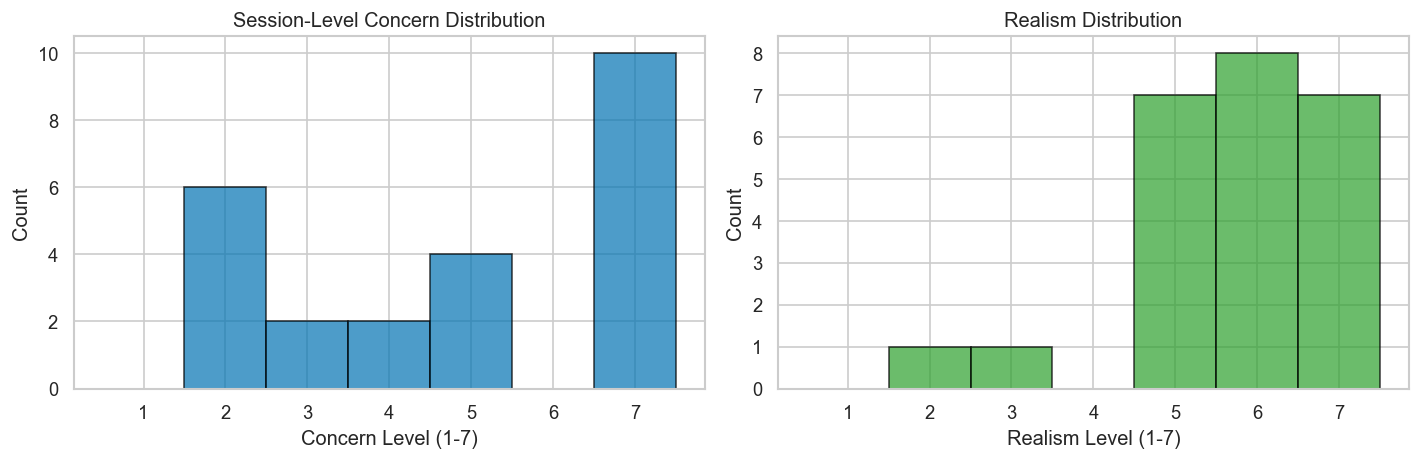


=== Cross-Tabulation: Sessions by Scenario Factors ===

age_band (4 levels):  ⚠ 4 levels below 10 obs
  9-12: n=6, mean concern=5.33
  13-15: n=7, mean concern=4.43
  16-18: n=5, mean concern=5.00
  6-8: n=6, mean concern=4.67

domain (3 levels):  ⚠ 2 levels below 10 obs
  Casual Knowledge Domain: n=13, mean concern=4.46
  Academic Domain: n=3, mean concern=5.33
  Relationship Domain: n=8, mean concern=5.25

sensitivity_level (3 levels):  ⚠ 2 levels below 10 obs
  available: n=5, mean concern=5.40
  intimate: n=4, mean concern=4.25
  sensitive: n=15, mean concern=4.80

relationship_frame (2 levels):
  tool: n=12, mean concern=4.58
  companion: n=12, mean concern=5.08

space_type (2 levels):
  shared_family_space: n=13, mean concern=4.85
  private_space: n=11, mean concern=4.82

breakdown_expected (2 levels):  ⚠ 1 levels below 10 obs
  no: n=20, mean concern=4.85
  yes: n=4, mean concern=4.75

trait (5 levels):  ⚠ 5 levels below 10 obs
  Agreeableness: n=2, mean concern=5.50
  Conscien

In [11]:
# ── Cell 0h: Descriptive Summary ─────────────────────────────────────────────

print('=' * 70)
print('DESCRIPTIVE SUMMARY')
print('=' * 70)

print(f'\nTotal moderation sessions (final): {len(df_session)}')
print(f'Total scenarios in data: {df_session["scenario_id"].nunique()}')
print(f'Total parents: {df_session["user_id"].nunique()}')

if not df_highlight.empty:
    print(f'Total highlights (exploded): {len(df_highlight)}')
if not selections_df.empty:
    print(f'Total text selections: {len(selections_df)}')

# Sessions per parent
spp = df_session.groupby('user_id').size()
print(f'\nSessions per parent: mean={spp.mean():.1f}, median={spp.median():.0f}, range=[{spp.min()}, {spp.max()}]')

# Sessions per scenario
sps = df_session.groupby('scenario_id').size()
print(f'Sessions per scenario: mean={sps.mean():.1f}, median={sps.median():.0f}, range=[{sps.min()}, {sps.max()}]')

# Concern level distribution
cl = df_session['concern_level'].dropna()
print(f'\nConcern level distribution (session-level, 1=Very negative, 7=Very positive):')
print(f'  mean={cl.mean():.2f}, median={cl.median():.1f}, SD={cl.std():.2f}')
val_counts = df_session['valence'].value_counts()
for v in ['positive', 'neutral', 'negative']:
    n = val_counts.get(v, 0)
    print(f'  {v}: {n} ({100*n/len(df_session):.1f}%)')

# Concern level histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(cl, bins=np.arange(0.5, 8.5, 1), edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Concern Level (1-7)')
axes[0].set_ylabel('Count')
axes[0].set_title('Session-Level Concern Distribution')
axes[0].set_xticks(range(1, 8))

rl = df_session['realism_level'].dropna()
axes[1].hist(rl, bins=np.arange(0.5, 8.5, 1), edgecolor='black', alpha=0.7, color='#2ca02c')
axes[1].set_xlabel('Realism Level (1-7)')
axes[1].set_ylabel('Count')
axes[1].set_title('Realism Distribution')
axes[1].set_xticks(range(1, 8))
plt.tight_layout()
plt.show()

# Cross-tabulations by scenario factors
print('\n=== Cross-Tabulation: Sessions by Scenario Factors ===')
for factor in SCENARIO_FACTORS:
    if factor in df_session.columns:
        ct = df_session[factor].value_counts().sort_index()
        if ct.empty:
            continue
        small_cells = ct[ct < MIN_OBS_PER_CELL]
        flag = f'  \u26a0 {len(small_cells)} levels below {MIN_OBS_PER_CELL} obs' if len(small_cells) > 0 else ''
        print(f'\n{factor} ({len(ct)} levels):{flag}')
        for level, count in ct.items():
            mean_cl = df_session.loc[df_session[factor] == level, 'concern_level'].mean()
            print(f'  {level}: n={count}, mean concern={mean_cl:.2f}')

---
## Utility: Export Highlights to CSV for Coding

This section exports highlight data for manual or LLM coding of response characteristics
and concern types. Run this section independently — it only requires data loading (Part 0).

In [12]:
# ── Export Highlights for Coding ──────────────────────────────────────────────

CODING_OUTPUT_DIR = OUTPUT_DIR
os.makedirs(CODING_OUTPUT_DIR, exist_ok=True)

# ── Export 1: One row per highlight ──
if not df_highlight.empty:
    # Get prompt and response text from moderation sessions
    prompt_response_map = (
        moderation_df[['scenario_id', 'scenario_prompt', 'original_response']]
        .dropna(subset=['scenario_id'])
        .drop_duplicates('scenario_id')
        .set_index('scenario_id')
    )

    export_hl = df_highlight.copy()
    # Add prompt/response text
    export_hl = export_hl.merge(
        prompt_response_map[['scenario_prompt', 'original_response']],
        left_on='scenario_id', right_index=True, how='left'
    )

    export_cols = [
        'concern_item_id', 'scenario_id', 'parent_id',
        'scenario_prompt', 'original_response',
        'highlight_text', 'highlight_sentiment', 'rationale_text',
    ]
    # Add offsets if available
    for c in ['start_offset', 'end_offset', 'source', 'selection_id']:
        if c in export_hl.columns:
            export_cols.append(c)
    # Add scenario context
    for c in ['age_band', 'domain', 'sensitivity_level']:
        if c in export_hl.columns:
            export_cols.append(c)

    # Add empty coding columns
    export_hl['response_characteristic_codes'] = ''
    export_hl['concern_codes'] = ''
    export_hl['coder_notes'] = ''
    export_cols += ['response_characteristic_codes', 'concern_codes', 'coder_notes']

    # Filter to available columns
    export_cols = [c for c in export_cols if c in export_hl.columns]
    export_hl = export_hl[export_cols]

    hl_path = os.path.join(CODING_OUTPUT_DIR, 'highlights_for_coding.csv')
    export_hl.to_csv(hl_path, index=False)
    print(f'Exported {len(export_hl)} highlights to: {hl_path}')
else:
    # Fallback: use selections directly
    if not selections_df.empty:
        export_sel = selections_df.copy()
        prompt_response_map = (
            moderation_df[['scenario_id', 'scenario_prompt', 'original_response']]
            .dropna(subset=['scenario_id'])
            .drop_duplicates('scenario_id')
            .set_index('scenario_id')
        )
        export_sel = export_sel.merge(
            prompt_response_map, left_on='scenario_id', right_index=True, how='left'
        )
        export_sel['response_characteristic_codes'] = ''
        export_sel['concern_codes'] = ''
        export_sel['coder_notes'] = ''

        hl_path = os.path.join(CODING_OUTPUT_DIR, 'highlights_for_coding.csv')
        export_sel.to_csv(hl_path, index=False)
        print(f'Exported {len(export_sel)} selections to: {hl_path}')
    else:
        print('No highlights or selections to export.')

# ── Export 2: One row per unique response (for response-level coding) ──
if not moderation_df.empty:
    # Unique responses with all highlights from any parent
    _final = moderation_df.copy()
    if 'is_final_version' in _final.columns:
        _final['is_final_version'] = _final['is_final_version'].astype(str).str.strip().str.lower()
        _final = _final[_final['is_final_version'].isin(['true', '1'])]

    # Aggregate highlights per scenario
    response_rows = []
    for sid, grp in _final.groupby('scenario_id'):
        all_hls = []
        for _, row in grp.iterrows():
            hls = parse_highlights_json(row.get('highlighted_texts', '[]'))
            all_hls.extend(hls)
        # Deduplicate highlight texts
        unique_hl_texts = []
        seen = set()
        for h in all_hls:
            txt = str(h) if not isinstance(h, str) else h
            if txt not in seen:
                seen.add(txt)
                unique_hl_texts.append(txt)

        response_rows.append({
            'scenario_id': sid,
            'prompt_text': grp.iloc[0].get('scenario_prompt', ''),
            'response_text': grp.iloc[0].get('original_response', ''),
            'all_highlighted_spans': ' ||| '.join(unique_hl_texts),
            'n_parents_reviewed': grp['user_id'].nunique(),
            'n_highlights_total': len(unique_hl_texts),
            'response_characteristic_codes': '',
            'coder_notes': '',
        })

    responses_export = pd.DataFrame(response_rows)
    resp_path = os.path.join(CODING_OUTPUT_DIR, 'responses_for_coding.csv')
    responses_export.to_csv(resp_path, index=False)
    print(f'Exported {len(responses_export)} unique responses to: {resp_path}')
    print(f'\nTotal unique scenarios: {len(responses_export)}')
else:
    print('No moderation data to export responses from.')

Exported 65 highlights to: /Users/johndriscoll/ParentalControl/DSL-kidsgpt-open-webui/data-exports/20260402_141950_PILOT6/contextual_analysis_output/highlights_for_coding.csv
Exported 21 unique responses to: /Users/johndriscoll/ParentalControl/DSL-kidsgpt-open-webui/data-exports/20260402_141950_PILOT6/contextual_analysis_output/responses_for_coding.csv

Total unique scenarios: 21


---
## Part 1: Do Parental Concerns Vary by Context?

Tests whether the addition of context factors (scenario content × parent covariates) and
their interactions significantly improves prediction of parental concern ratings.

**Core test:** Likelihood ratio test comparing the interaction model vs main-effects model.

In [13]:
# ── Cell 1a: Power Check & Model Strategy ────────────────────────────────────

print('=== Data Sufficiency Check ===')
strategy, n_obs, n_parents, n_scenarios = power_check(
    df_session, parent_col='user_id', scenario_col='scenario_id'
)

# Determine which factors have enough variation
usable_factors = []
for f in SCENARIO_FACTORS:
    if f in df_session.columns:
        n_levels = df_session[f].nunique()
        min_cell = df_session[f].value_counts().min()
        if n_levels >= 2 and min_cell >= 2:
            usable_factors.append(f)
        else:
            print(f'  Dropping {f}: {n_levels} levels, min cell={min_cell}')

usable_covariates = []
for c in PARENT_COVARIATES:
    if c in df_session.columns:
        n_levels = df_session[c].nunique()
        if n_levels >= 2:
            usable_covariates.append(c)

print(f'\nUsable scenario factors: {usable_factors}')
print(f'Usable parent covariates: {usable_covariates}')
print(f'Model strategy: {strategy}')

=== Data Sufficiency Check ===
Observations: 24 (need ≥50 for mixed models)
Parents: 6 (need ≥8 for random effect)
Scenarios: 21 (need ≥8 for random effect)
⚠ Insufficient for mixed models. Using OLS with clustered SEs.

Usable scenario factors: ['age_band', 'domain', 'sensitivity_level', 'relationship_frame', 'space_type', 'breakdown_expected', 'trait', 'trait_level', 'gender_identity']
Usable parent covariates: ['parent_gender', 'parent_age_group', 'parent_education', 'genai_familiarity', 'genai_usage_frequency']
Model strategy: ols_clustered


In [14]:
# ── Cell 1b: Continuous Outcome Models (Concern Level) ───────────────────────

# Prepare clean analysis subset
model_df = df_session.dropna(subset=['concern_level']).copy()

# Drop rows with missing factors
for f in usable_factors:
    model_df = model_df.dropna(subset=[f])
print(f'Analysis N after dropping missing: {len(model_df)}')

model_results = {}

if len(model_df) < 5:
    print('\u26a0 Too few observations for any modeling. Showing descriptive statistics only.')
else:
    # ── Model 1: Null (intercept-only) ──
    print('\n--- Model 1: Null (Intercept Only) ---')
    if strategy in ('mixed_crossed', 'mixed_parent_only'):
        try:
            vc = {'scenario_id': '0 + C(scenario_id)'} if strategy == 'mixed_crossed' else None
            m1 = mixedlm('concern_level ~ 1', model_df, groups=model_df['user_id'],
                         vc_formula=vc).fit(reml=True)
            model_results['null'] = m1

            # ICC calculation
            var_parent = m1.cov_re.iloc[0, 0] if hasattr(m1.cov_re, 'iloc') else float(m1.cov_re)
            var_resid = m1.scale
            var_scenario = 0
            if vc and hasattr(m1, 'vcomp'):
                var_scenario = float(m1.vcomp[0]) if len(m1.vcomp) > 0 else 0
            var_total = var_parent + var_scenario + var_resid
            icc_parent = var_parent / var_total
            icc_scenario = var_scenario / var_total

            print(f'  Variance - Parent: {var_parent:.3f} (ICC={icc_parent:.3f})')
            print(f'  Variance - Scenario: {var_scenario:.3f} (ICC={icc_scenario:.3f})')
            print(f'  Variance - Residual: {var_resid:.3f}')
            print(f'  Observations: {int(m1.nobs)}, Groups: {m1.k_re}')

            # ICC bar chart
            fig, ax = plt.subplots(figsize=(6, 4))
            bars = ax.bar(['Parent', 'Scenario', 'Residual'],
                          [var_parent, var_scenario, var_resid],
                          color=['#1f77b4', '#ff7f0e', '#7f7f7f'])
            ax.set_ylabel('Variance')
            ax.set_title('Variance Decomposition (Null Model)')
            for bar, val in zip(bars, [icc_parent, icc_scenario, 1 - icc_parent - icc_scenario]):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{val:.1%}', ha='center', fontsize=10)
            plt.tight_layout()
            plt.savefig(os.path.join(OUTPUT_DIR, 'icc_variance_decomposition.png'), bbox_inches='tight')
            plt.show()
        except Exception as e:
            print(f'  Mixed null model failed: {e}')
            print('  Computing ICC via pingouin instead.')
            try:
                icc_result = pg.intraclass_corr(
                    data=model_df, targets='scenario_id', raters='user_id',
                    ratings='concern_level'
                )
                display(icc_result)
            except Exception as e2:
                print(f'  ICC calculation also failed: {e2}')
    else:
        # Simple variance decomposition without mixed model
        print('  Using one-way ANOVA decomposition (no random effects).')
        for grouping, label in [('user_id', 'Parent'), ('scenario_id', 'Scenario')]:
            groups_data = [g['concern_level'].dropna().values
                           for _, g in model_df.groupby(grouping)
                           if len(g['concern_level'].dropna()) > 0]
            if len(groups_data) >= 2:
                H, p = kruskal(*groups_data)
                print(f'  Kruskal-Wallis by {label}: H={H:.2f}, p={p:.4f}')

    # ── Model 2: Main Effects ──
    print('\n--- Model 2: Main Effects ---')
    main_terms = [f'C({f})' for f in usable_factors] + [f'C({c})' for c in usable_covariates]
    if main_terms:
        formula_main = 'concern_level ~ ' + ' + '.join(main_terms)
        print(f'  Formula: {formula_main}')
        n_terms = sum(model_df[f].nunique() - 1 for f in usable_factors + usable_covariates
                      if f in model_df.columns)
        print(f'  Estimated terms: {n_terms}, obs/term ratio: {len(model_df)/max(n_terms,1):.1f}')

        r2 = fit_mixed_or_fallback(
            formula_main, model_df, 'user_id',
            vc_formula={'scenario_id': '0 + C(scenario_id)'} if strategy == 'mixed_crossed' else None
        )
        model_results['main'] = r2
        if r2['converged']:
            print(r2['summary'])
    else:
        print('  No usable predictors. Skipping main effects model.')

    # ── Model 3: Interactions ──
    print('\n--- Model 3: Interactions ---')
    # Check feasibility: compute number of interaction terms
    if len(usable_factors) >= 2:
        # Pairwise interactions among scenario factors only (most interpretable)
        interaction_pairs = []
        for i, f1 in enumerate(usable_factors):
            for f2 in usable_factors[i+1:]:
                n_terms_pair = (model_df[f1].nunique() - 1) * (model_df[f2].nunique() - 1)
                interaction_pairs.append((f1, f2, n_terms_pair))

        total_interaction_terms = sum(t for _, _, t in interaction_pairs)
        obs_per_term = len(model_df) / max(total_interaction_terms + n_terms, 1)
        print(f'  Total interaction terms (all pairs): {total_interaction_terms}')
        print(f'  Obs-per-term ratio: {obs_per_term:.1f}')

        if obs_per_term < MIN_OBS_PER_CELL:
            print(f'  \u26a0 Ratio below {MIN_OBS_PER_CELL}. Fitting interactions one family at a time.')
            # Fit each interaction pair separately
            interaction_results = []
            for f1, f2, nt in interaction_pairs:
                pair_formula = f'concern_level ~ C({f1}) * C({f2})'
                try:
                    r = fit_mixed_or_fallback(pair_formula, model_df, 'user_id')
                    if r['converged']:
                        interaction_results.append({
                            'pair': f'{f1} x {f2}',
                            'n_terms': nt,
                            'result': r
                        })
                except Exception:
                    pass
            model_results['interactions_by_pair'] = interaction_results
            print(f'  Fitted {len(interaction_results)} interaction pairs.')
        else:
            # Fit full interaction model
            interaction_terms = [f'C({f1}):C({f2})' for f1, f2, _ in interaction_pairs]
            formula_int = formula_main + ' + ' + ' + '.join(interaction_terms)
            r3 = fit_mixed_or_fallback(formula_int, model_df, 'user_id')
            model_results['interaction'] = r3
            if r3['converged']:
                print(r3['summary'])

                # LRT: Model 3 vs Model 2
                if model_results.get('main', {}).get('converged'):
                    m2 = model_results['main']['model']
                    m3 = r3['model']
                    if hasattr(m2, 'llf') and hasattr(m3, 'llf'):
                        lrt_stat = 2 * (m3.llf - m2.llf)
                        lrt_df = m3.df_modelwc - m2.df_modelwc if hasattr(m3, 'df_modelwc') else total_interaction_terms
                        lrt_p = chi2.sf(lrt_stat, lrt_df)
                        print(f'\n  LRT (Model 3 vs Model 2): \u03c7\u00b2({lrt_df}) = {lrt_stat:.2f}, p = {lrt_p:.4f}')
                        if lrt_p < ALPHA:
                            print(f'  \u2714 Interaction model significantly improves fit (p < {ALPHA}).')
                            print('  Conclusion: Parental concerns ARE contextually dependent.')
                        else:
                            print(f'  \u2716 Interaction model does NOT significantly improve fit (p = {lrt_p:.4f}).')
    else:
        print('  Fewer than 2 usable factors. Cannot test interactions.')

    # ── Nonparametric supplement: Kruskal-Wallis per factor ──
    print('\n--- Nonparametric Tests (Kruskal-Wallis per factor) ---')
    kw_results = []
    for f in usable_factors:
        groups = [g['concern_level'].dropna().values
                  for _, g in model_df.groupby(f)
                  if len(g['concern_level'].dropna()) >= 1]
        if len(groups) >= 2:
            H, p = kruskal(*groups)
            kw_results.append({'Factor': f, 'H': H, 'p': p,
                               'Significant': '*' if p < ALPHA else ''})
    if kw_results:
        kw_df = pd.DataFrame(kw_results)
        display(kw_df)

Analysis N after dropping missing: 24

--- Model 1: Null (Intercept Only) ---
  Using one-way ANOVA decomposition (no random effects).
  Kruskal-Wallis by Parent: H=10.63, p=0.0592
  Kruskal-Wallis by Scenario: H=20.52, p=0.4258

--- Model 2: Main Effects ---
  Formula: concern_level ~ C(age_band) + C(domain) + C(sensitivity_level) + C(relationship_frame) + C(space_type) + C(breakdown_expected) + C(trait) + C(trait_level) + C(gender_identity) + C(parent_gender) + C(parent_age_group) + C(parent_education) + C(genai_familiarity) + C(genai_usage_frequency)
  Estimated terms: 26, obs/term ratio: 0.9
Mixed model failed: Singular matrix
Falling back to OLS with clustered standard errors.
                            OLS Regression Results                            
Dep. Variable:          concern_level   R-squared:                       0.902
Model:                            OLS   Adj. R-squared:                 -1.246
Method:                 Least Squares   F-statistic:                 2.2

/opt/homebrew/Caskroom/miniforge/base/envs/open-webui/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1561: RuntimeWarning: invalid value encountered in log
  np.log(self.n_totobs - self.k_fe) / 2.)
/opt/homebrew/Caskroom/miniforge/base/envs/open-webui/lib/python3.11/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/homebrew/Caskroom/miniforge/base/envs/open-webui/lib/python3.11/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/homebrew/Caskroom/miniforge/base/envs/open-webui/lib/python3.11/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/opt/homebrew/Caskroom/miniforge/base/envs/open-webui/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of 

,Factor,H,p,Significant
0,age_band,0.672774,0.879588,
1,domain,0.950637,0.621687,
2,sensitivity_level,0.632647,0.728824,
3,relationship_frame,0.444285,0.505062,
4,space_type,0.000000,1.000000,
5,breakdown_expected,0.026437,0.870838,
6,trait,3.346508,0.501597,
7,trait_level,1.652299,0.198646,
8,gender_identity,2.310979,0.314903,


In [15]:
# ── Cell 1c: Binary Outcome Models (Valence) ────────────────────────────────

valence_df = model_df[model_df['valence_binary'].notna()].copy()
print(f'Binary valence analysis: {len(valence_df)} rows '
      f'(excluded {len(model_df) - len(valence_df)} neutral ratings)')
print(f'  Positive: {(valence_df["valence_binary"] == 1).sum()}')
print(f'  Negative: {(valence_df["valence_binary"] == 0).sum()}')

if len(valence_df) >= 10 and valence_df['valence_binary'].nunique() == 2:
    # Main effects logistic model
    main_terms_v = [f'C({f})' for f in usable_factors]
    if main_terms_v:
        formula_v = 'valence_binary ~ ' + ' + '.join(main_terms_v)
        print(f'\nFormula: {formula_v}')

        r_val = fit_mixed_or_fallback(
            formula_v, valence_df, 'user_id', family='binomial'
        )
        model_results['valence_main'] = r_val
        if r_val['converged']:
            print(r_val['summary'])
            # Report odds ratios
            if hasattr(r_val['model'], 'params'):
                or_df = pd.DataFrame({
                    'Odds Ratio': np.exp(r_val['model'].params),
                    'CI Lower': np.exp(r_val['model'].conf_int()[0]),
                    'CI Upper': np.exp(r_val['model'].conf_int()[1]),
                    'p-value': r_val['model'].pvalues,
                })
                print('\nOdds Ratios:')
                display(or_df)
else:
    print('\u26a0 Insufficient data for binary valence model.')
    # Descriptive: proportion positive by factor
    for f in usable_factors:
        if f in valence_df.columns:
            ct = valence_df.groupby(f)['valence_binary'].agg(['mean', 'count'])
            ct.columns = ['Proportion Positive', 'N']
            if len(ct) > 0:
                print(f'\n{f}:')
                display(ct)

Binary valence analysis: 22 rows (excluded 2 neutral ratings)
  Positive: 14
  Negative: 8

Formula: valence_binary ~ C(age_band) + C(domain) + C(sensitivity_level) + C(relationship_frame) + C(space_type) + C(breakdown_expected) + C(trait) + C(trait_level) + C(gender_identity)
                               GEE Regression Results                              
Dep. Variable:              valence_binary   No. Observations:                   22
Model:                                 GEE   No. clusters:                        6
Method:                        Generalized   Min. cluster size:                   3
                      Estimating Equations   Max. cluster size:                   4
Family:                           Binomial   Mean cluster size:                 3.7
Dependence structure:         Independence   Num. iterations:                     2
Date:                     Fri, 03 Apr 2026   Scale:                           1.000
Covariance type:                    robust   Time:

/opt/homebrew/Caskroom/miniforge/base/envs/open-webui/lib/python3.11/site-packages/statsmodels/genmod/generalized_estimating_equations.py:1842: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_robust))
/opt/homebrew/Caskroom/miniforge/base/envs/open-webui/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Odds Ratio,CI Lower,CI Upper,p-value
Intercept,1.141065e+116,0.0,inf,0.999999
C(age_band)[T.13-15],1.009771e+106,0.0,inf,0.999999
C(age_band)[T.16-18],7.968870e+108,0.0,inf,0.999998
C(age_band)[T.6-8],5.310928e+18,NaN,NaN,NaN
C(domain)[T.Academic Domain],6.162448e-115,0.0,inf,0.999998
C(domain)[T.Relationship Domain],9.620420e-06,0.0,inf,0.999215
C(sensitivity_level)[T.intimate],1.305683e-84,NaN,NaN,NaN
C(sensitivity_level)[T.sensitive],1.605743e-06,0.0,inf,0.998301
C(relationship_frame)[T.companion],1.898067e+53,0.0,inf,0.992932
C(space_type)[T.private_space],2.385999e-22,NaN,NaN,NaN


Diagnostics for: main model (ols_clustered)


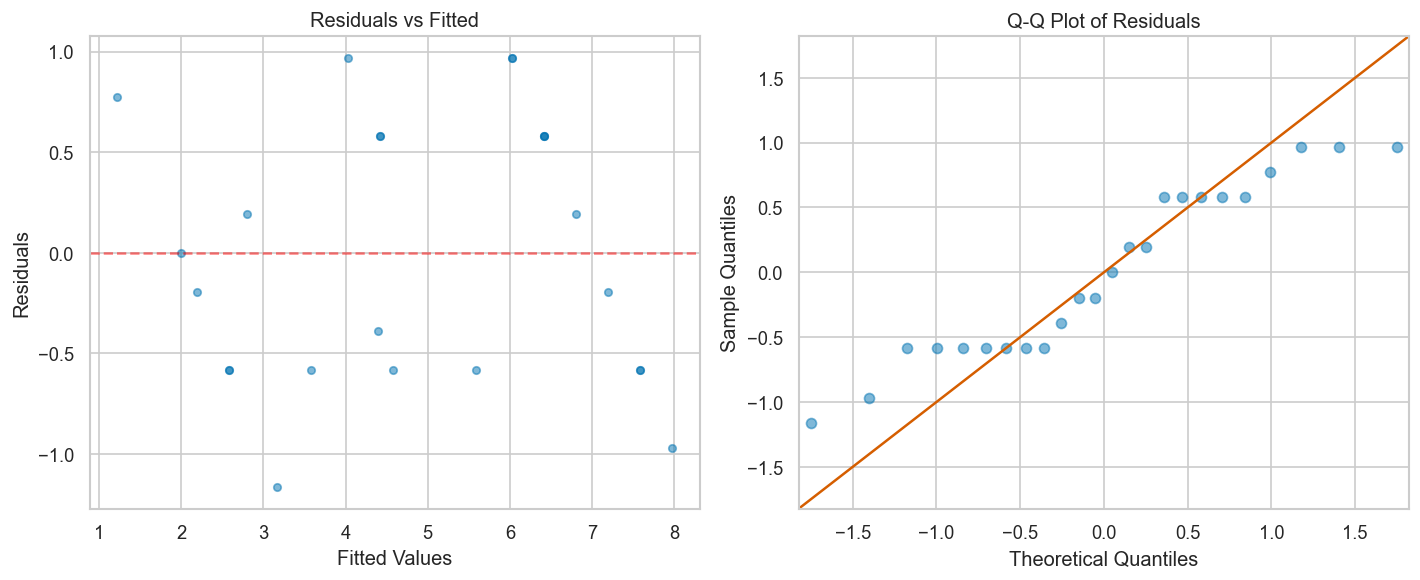

R²: 0.9024
Adjusted R²: -1.2457


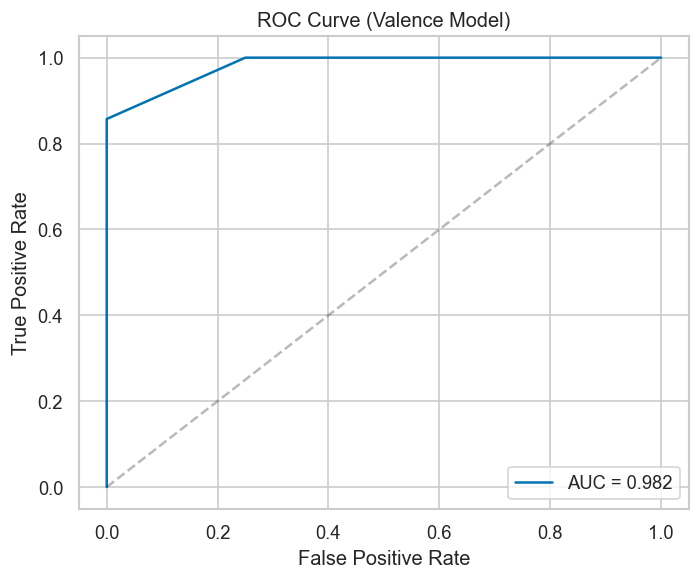

AUC: 0.982


In [16]:
# ── Cell 1d: Model Diagnostics ───────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Find the best continuous model we fitted
best_continuous = None
for key in ['interaction', 'main']:
    if model_results.get(key, {}).get('converged'):
        best_continuous = model_results[key]['model']
        print(f'Diagnostics for: {key} model ({model_results[key]["model_type"]})')
        break

if best_continuous is not None and hasattr(best_continuous, 'resid'):
    resid = best_continuous.resid
    fitted = best_continuous.fittedvalues

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Residual vs fitted
    axes[0].scatter(fitted, resid, alpha=0.5, s=20)
    axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
    axes[0].set_xlabel('Fitted Values')
    axes[0].set_ylabel('Residuals')
    axes[0].set_title('Residuals vs Fitted')

    # QQ plot
    sm.qqplot(resid, line='45', ax=axes[1], alpha=0.5)
    axes[1].set_title('Q-Q Plot of Residuals')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'model_diagnostics.png'), bbox_inches='tight')
    plt.show()

    # R-squared for OLS models
    if hasattr(best_continuous, 'rsquared'):
        print(f'R\u00b2: {best_continuous.rsquared:.4f}')
        print(f'Adjusted R\u00b2: {best_continuous.rsquared_adj:.4f}')
else:
    print('No fitted continuous model available for diagnostics.')

# Binary model diagnostics
best_binary = model_results.get('valence_main', {}).get('model')
if best_binary is not None and hasattr(best_binary, 'predict'):
    try:
        from sklearn.metrics import roc_auc_score, roc_curve
        y_true = valence_df['valence_binary'].values
        y_pred = best_binary.predict(valence_df)

        fpr, tpr, _ = roc_curve(y_true, y_pred)
        auc = roc_auc_score(y_true, y_pred)

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title('ROC Curve (Valence Model)')
        ax.legend()
        plt.tight_layout()
        plt.show()
        print(f'AUC: {auc:.3f}')
    except ImportError:
        print('scikit-learn not available for ROC/AUC computation.')
    except Exception as e:
        print(f'Binary diagnostics failed: {e}')

---
## Part 2: Which Contexts Are Most Influential?

Ranks interaction effects by standardized effect size and visualizes the most
influential context combinations through marginal effect plots.

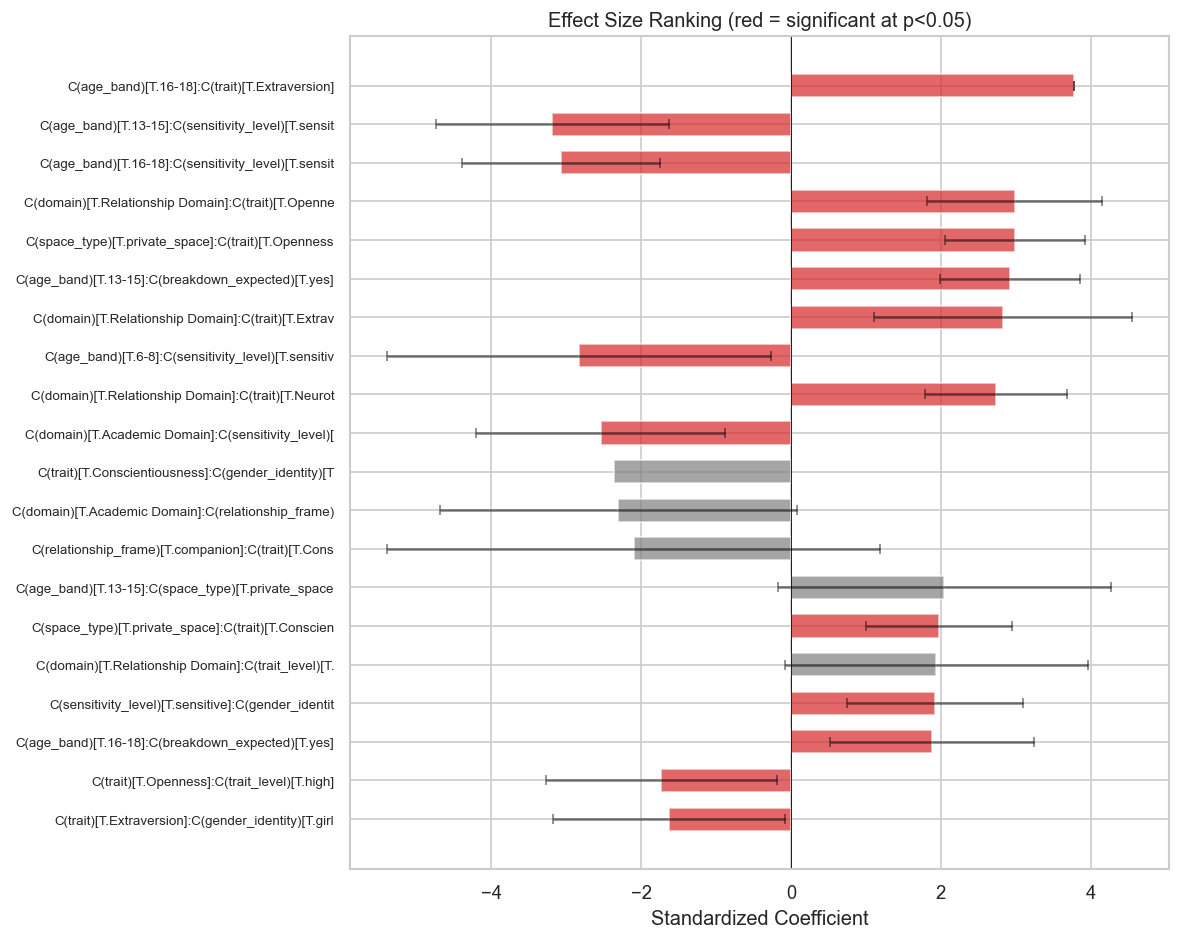


Significant effects (p < 0.05): 26


KeyError: 'abs_std_coef'

In [17]:
# ── Cell 2a: Effect Size Ranking ─────────────────────────────────────────────

def extract_effects(model_result_dict, model_key='interaction'):
    """Extract coefficients, CIs, and p-values from a fitted model."""
    r = model_result_dict.get(model_key, {})
    if not r.get('converged'):
        # Try pair-wise results
        if model_result_dict.get('interactions_by_pair'):
            all_effects = []
            for pair_info in model_result_dict['interactions_by_pair']:
                pr = pair_info['result']
                if pr.get('converged'):
                    m = pr['model']
                    effects = pd.DataFrame({
                        'coef': m.params,
                        'se': m.bse,
                        'p': m.pvalues,
                        'ci_lower': m.conf_int()[0],
                        'ci_upper': m.conf_int()[1],
                    })
                    # Keep only interaction terms
                    effects = effects[effects.index.str.contains(':')]
                    effects['pair'] = pair_info['pair']
                    all_effects.append(effects)
            if all_effects:
                return pd.concat(all_effects)
        # Try main effects model
        r = model_result_dict.get('main', {})
        if not r.get('converged'):
            return pd.DataFrame()

    m = r['model']
    effects = pd.DataFrame({
        'coef': m.params,
        'se': m.bse,
        'p': m.pvalues,
        'ci_lower': m.conf_int()[0],
        'ci_upper': m.conf_int()[1],
    })
    return effects


effects_df = extract_effects(model_results)

if not effects_df.empty:
    # Remove intercept
    effects_df = effects_df[effects_df.index != 'Intercept']

    # Standardize coefficients by outcome SD
    outcome_sd = model_df['concern_level'].std()
    effects_df['std_coef'] = effects_df['coef'] / outcome_sd
    effects_df['abs_std_coef'] = effects_df['std_coef'].abs()
    effects_df['significant'] = effects_df['p'] < ALPHA

    # Sort by absolute effect size
    effects_df = effects_df.sort_values('abs_std_coef', ascending=True)

    # Forest plot
    sig_effects = effects_df[effects_df['significant']]
    plot_effects = effects_df.tail(20)  # Top 20 by effect size

    if len(plot_effects) > 0:
        fig, ax = plt.subplots(figsize=(10, max(4, len(plot_effects) * 0.4)))
        colors = ['#d62728' if s else '#7f7f7f' for s in plot_effects['significant']]
        y_pos = range(len(plot_effects))

        ax.barh(y_pos, plot_effects['std_coef'], color=colors, alpha=0.7, height=0.6)
        ax.errorbar(plot_effects['std_coef'], y_pos,
                    xerr=[plot_effects['std_coef'] - plot_effects['ci_lower']/outcome_sd,
                          plot_effects['ci_upper']/outcome_sd - plot_effects['std_coef']],
                    fmt='none', color='black', alpha=0.5, capsize=3)
        ax.axvline(0, color='black', linestyle='-', linewidth=0.5)
        ax.set_yticks(y_pos)
        ax.set_yticklabels([n[:50] for n in plot_effects.index], fontsize=8)
        ax.set_xlabel('Standardized Coefficient')
        ax.set_title(f'Effect Size Ranking (red = significant at p<{ALPHA})')
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, 'interaction_forest_plot.png'), bbox_inches='tight')
        plt.show()

    # Summary table of significant effects
    if len(sig_effects) > 0:
        print(f'\nSignificant effects (p < {ALPHA}): {len(sig_effects)}')
        display(sig_effects[['coef', 'se', 'p', 'std_coef']].sort_values('abs_std_coef', ascending=False))
    else:
        print('No significant effects found.')
else:
    print('No model effects to rank. Showing group mean differences instead.')
    # Descriptive effect sizes: mean concern by factor level
    for f in usable_factors:
        grp_means = model_df.groupby(f)['concern_level'].agg(['mean', 'std', 'count'])
        if len(grp_means) >= 2:
            print(f'\n{f}:')
            display(grp_means.round(2))

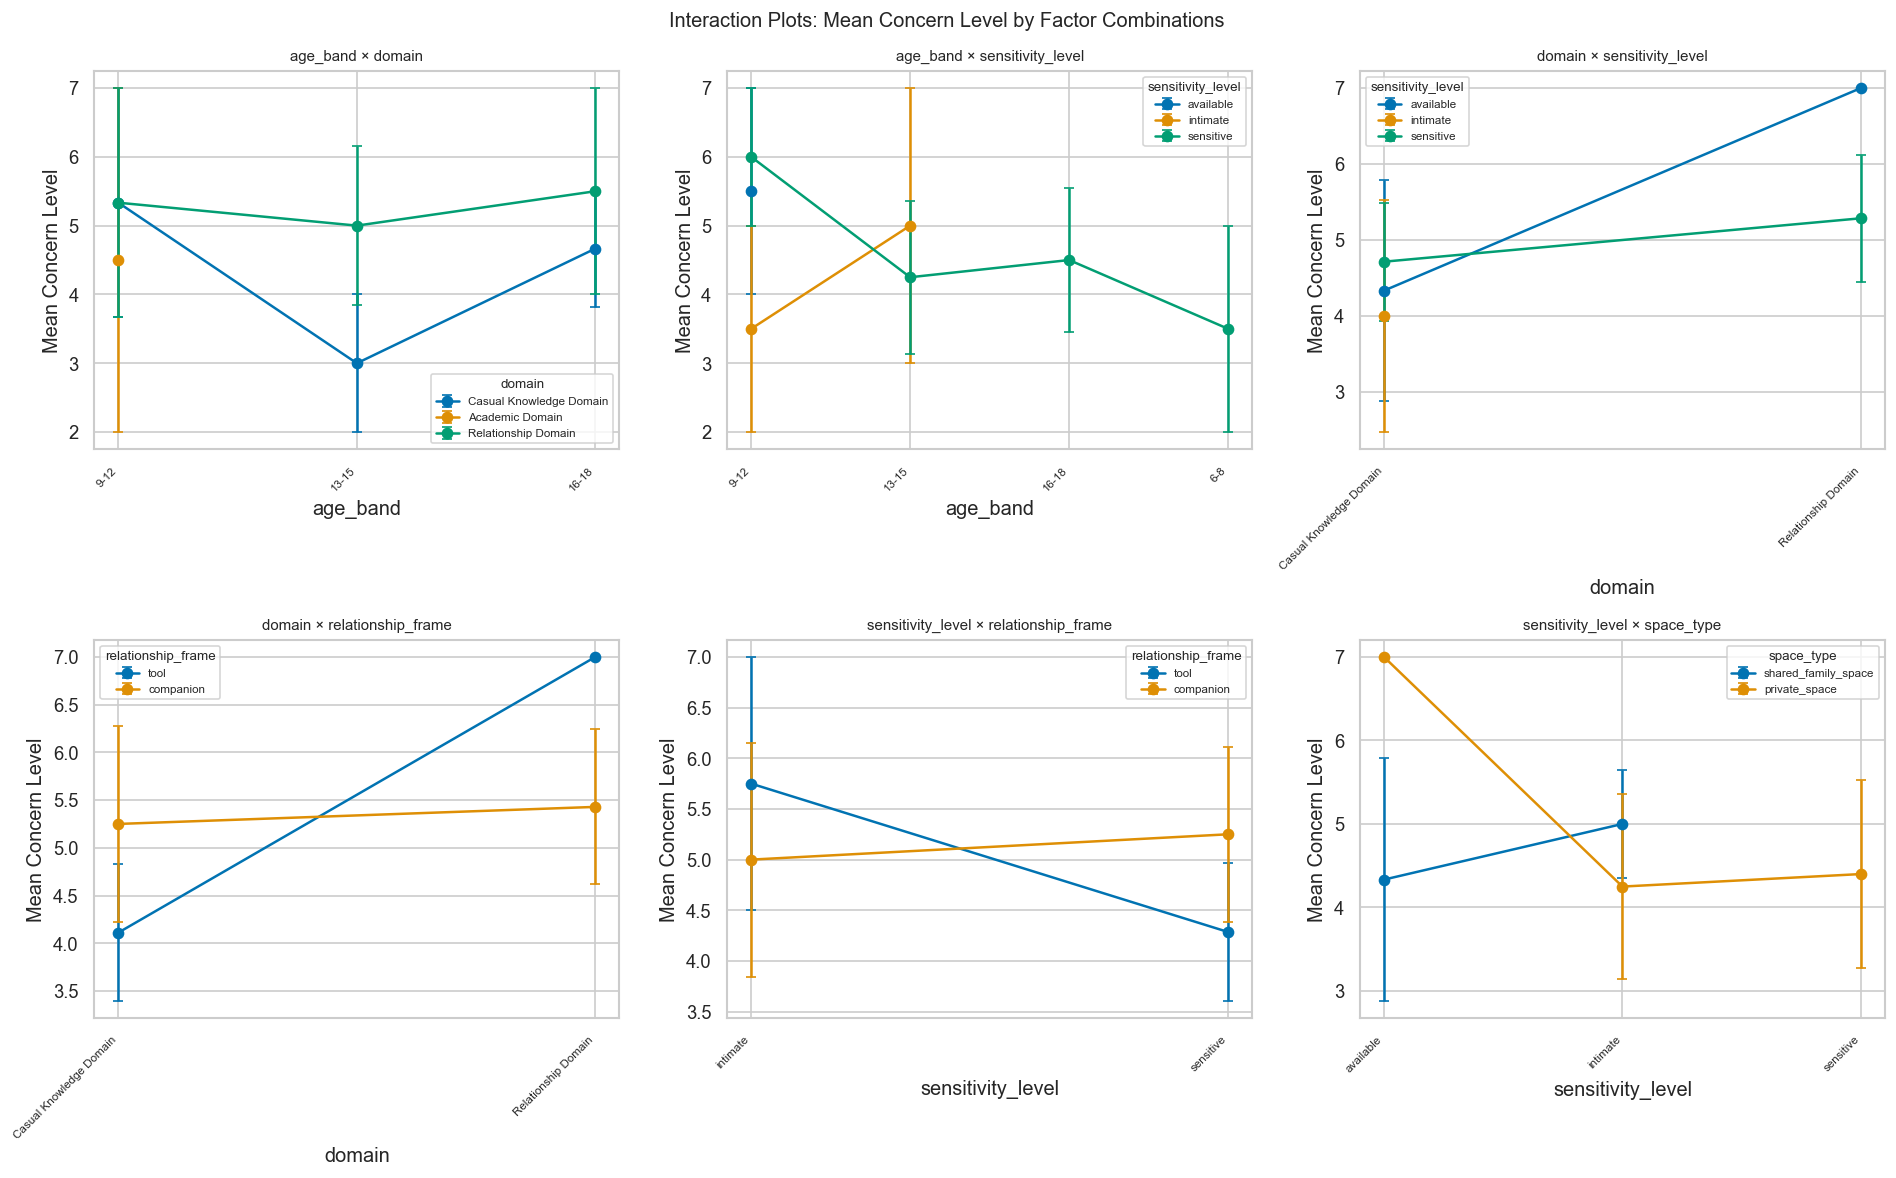

In [18]:
# ── Cell 2b: Marginal Effects / Interaction Plots ────────────────────────────

# Plot predicted concern by factor levels (even without interaction model,
# this shows how concern varies across contexts)

# Select factors with enough variation for meaningful plots
plot_factors = [f for f in usable_factors if model_df[f].nunique() >= 2]

if len(plot_factors) >= 2:
    n_plots = min(6, len(plot_factors) * (len(plot_factors) - 1) // 2)
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    plot_idx = 0

    for i, f1 in enumerate(plot_factors[:4]):
        for f2 in plot_factors[i+1:min(i+3, len(plot_factors))]:
            if plot_idx >= 6:
                break
            ax = axes[plot_idx]
            # Group means
            grp = model_df.groupby([f1, f2])['concern_level'].agg(['mean', 'sem', 'count']).reset_index()
            grp = grp[grp['count'] >= 2]  # Only plot cells with 2+ obs

            if len(grp) > 0:
                for level2, sub in grp.groupby(f2):
                    ax.errorbar(range(len(sub)), sub['mean'], yerr=sub['sem'],
                                marker='o', label=str(level2), capsize=3)
                    ax.set_xticks(range(len(sub)))
                    ax.set_xticklabels(sub[f1], rotation=45, ha='right', fontsize=7)
                ax.set_xlabel(f1)
                ax.set_ylabel('Mean Concern Level')
                ax.set_title(f'{f1} \u00d7 {f2}', fontsize=9)
                ax.legend(title=f2, fontsize=7, title_fontsize=8)
            plot_idx += 1

    # Hide unused axes
    for j in range(plot_idx, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Interaction Plots: Mean Concern Level by Factor Combinations', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'marginal_effects_plots.png'), bbox_inches='tight')
    plt.show()
elif len(plot_factors) >= 1:
    # Single-factor plots
    fig, axes = plt.subplots(1, len(plot_factors), figsize=(5 * len(plot_factors), 5))
    if len(plot_factors) == 1:
        axes = [axes]
    for ax, f in zip(axes, plot_factors):
        grp = model_df.groupby(f)['concern_level'].agg(['mean', 'sem']).reset_index()
        ax.bar(range(len(grp)), grp['mean'], yerr=grp['sem'], capsize=5, alpha=0.7)
        ax.set_xticks(range(len(grp)))
        ax.set_xticklabels(grp[f], rotation=45, ha='right')
        ax.set_ylabel('Mean Concern Level')
        ax.set_title(f)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'marginal_effects_plots.png'), bbox_inches='tight')
    plt.show()
else:
    print('Not enough factors for interaction plots.')

In [19]:
# ── Cell 2c: Sensitivity Analysis ────────────────────────────────────────────

print('=== Sensitivity Analyses ===')
sensitivity_results = {}

# 1. Collapse age_band to 2 levels
if 'age_band' in model_df.columns and model_df['age_band'].nunique() > 2:
    print('\n--- Sensitivity 1: Collapsed age_band (young=6-12, older=13-18) ---')
    sens_df = model_df.copy()
    sens_df['age_band_collapsed'] = sens_df['age_band'].apply(
        lambda x: 'young_6_12' if x in ['6-8', '9-12'] else 'older_13_18'
    )
    factors_collapsed = [f if f != 'age_band' else 'age_band_collapsed' for f in usable_factors]
    main_terms_s = [f'C({f})' for f in factors_collapsed]
    if main_terms_s:
        formula_s = 'concern_level ~ ' + ' + '.join(main_terms_s)
        r_s = fit_mixed_or_fallback(formula_s, sens_df, 'user_id')
        sensitivity_results['age_collapsed'] = r_s
        if r_s['converged']:
            sig_terms = r_s['model'].pvalues[r_s['model'].pvalues < ALPHA]
            print(f'  Significant terms: {len(sig_terms)}')
            if len(sig_terms) > 0:
                display(sig_terms)

# 2. Drop covariates with high missingness
print('\n--- Sensitivity 2: Drop high-missingness covariates (>20%) ---')
low_missing_covs = []
for c in usable_covariates:
    if c in model_df.columns:
        miss_rate = model_df[c].isna().mean()
        if miss_rate <= 0.20:
            low_missing_covs.append(c)
        else:
            print(f'  Dropping {c}: {miss_rate:.1%} missing')

if usable_factors:
    terms_s2 = [f'C({f})' for f in usable_factors]
    if low_missing_covs:
        terms_s2 += [f'C({c})' for c in low_missing_covs]
    formula_s2 = 'concern_level ~ ' + ' + '.join(terms_s2)
    r_s2 = fit_mixed_or_fallback(formula_s2, model_df.dropna(subset=usable_factors), 'user_id')
    sensitivity_results['no_missing_covs'] = r_s2
    if r_s2['converged']:
        sig_terms2 = r_s2['model'].pvalues[r_s2['model'].pvalues < ALPHA]
        print(f'  Significant terms: {len(sig_terms2)}')

# Robustness summary
print('\n--- Robustness Summary ---')
print('Terms significant across specifications:')
all_sig_terms = {}
for name, r in [('main', model_results.get('main', {})),
                ('age_collapsed', sensitivity_results.get('age_collapsed', {})),
                ('no_missing', sensitivity_results.get('no_missing_covs', {}))]:
    if isinstance(r, dict) and r.get('converged'):
        sig = set(r['model'].pvalues[r['model'].pvalues < ALPHA].index)
        for t in sig:
            all_sig_terms[t] = all_sig_terms.get(t, 0) + 1

robust = {t: c for t, c in all_sig_terms.items() if c >= 2 and t != 'Intercept'}
fragile = {t: c for t, c in all_sig_terms.items() if c == 1 and t != 'Intercept'}
if robust:
    print(f'  Robust (\u22652 specifications): {list(robust.keys())}')
if fragile:
    print(f'  Fragile (1 specification only): {list(fragile.keys())}')
if not robust and not fragile:
    print('  No significant terms found across specifications.')

=== Sensitivity Analyses ===

--- Sensitivity 1: Collapsed age_band (young=6-12, older=13-18) ---
  Significant terms: 0

--- Sensitivity 2: Drop high-missingness covariates (>20%) ---
Mixed model failed: Singular matrix
Falling back to OLS with clustered standard errors.
  Significant terms: 0

--- Robustness Summary ---
Terms significant across specifications:
  No significant terms found across specifications.


/opt/homebrew/Caskroom/miniforge/base/envs/open-webui/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/Caskroom/miniforge/base/envs/open-webui/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/open-webui/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/Caskroom/miniforge/base/envs/open-webui/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/open-w

---
## Part 3: Does Context Shape Concern Type?

**Requires concern codes (File 6).** If not available, this section is skipped.

Tests whether different contexts produce different *types* of concerns,
not just different *intensities*.

In [20]:
# ── Cell 3a: Gate Check ──────────────────────────────────────────────────────

HAS_CONCERN_CODES = not concern_codes_df.empty

if not HAS_CONCERN_CODES:
    print('=' * 70)
    print('PART 3 SKIPPED: Concern codes not yet available.')
    print('To enable this section:')
    print(f'  1. Code highlights using the exported CSV: {{OUTPUT_DIR}}/highlights_for_coding.csv')
    print(f'  2. Set CONCERN_CODES_FILE in the config cell to point to the coded CSV.')
    print('  3. Re-run the notebook.')
    print('=' * 70)

PART 3 SKIPPED: Concern codes not yet available.
To enable this section:
  1. Code highlights using the exported CSV: {OUTPUT_DIR}/highlights_for_coding.csv
  2. Set CONCERN_CODES_FILE in the config cell to point to the coded CSV.
  3. Re-run the notebook.


In [21]:
# ── Cell 3b: Concern Code Descriptives & Analysis ────────────────────────────

if HAS_CONCERN_CODES:
    print('=== Concern Code Analysis ===')

    # Merge concern codes with highlight data
    # Expected: concern_codes_df has 'highlight_id' and 'concern_code' columns
    _id_col = 'highlight_id' if 'highlight_id' in concern_codes_df.columns else 'concern_item_id'
    codes_merged = df_highlight.merge(
        concern_codes_df, left_on='concern_item_id', right_on=_id_col, how='inner'
    ) if not df_highlight.empty else concern_codes_df.copy()

    if 'concern_code' in codes_merged.columns and len(codes_merged) > 0:
        # Frequency of each concern code
        code_freq = codes_merged['concern_code'].value_counts()
        print(f'\nConcern code frequencies ({len(code_freq)} unique codes):')
        display(code_freq)

        # Co-occurrence
        codes_per_highlight = codes_merged.groupby('concern_item_id')['concern_code'].apply(list)
        multi_code = codes_per_highlight[codes_per_highlight.apply(len) > 1]
        print(f'\nHighlights with multiple codes: {len(multi_code)}/{len(codes_per_highlight)} '
              f'({100*len(multi_code)/max(len(codes_per_highlight),1):.1f}%)')

        # Heatmap: concern code frequency by age_band x domain
        for context_var in ['age_band', 'domain', 'sensitivity_level']:
            if context_var in codes_merged.columns:
                ct = pd.crosstab(codes_merged[context_var], codes_merged['concern_code'])
                if ct.shape[0] >= 2 and ct.shape[1] >= 2:
                    fig, ax = plt.subplots(figsize=(max(8, ct.shape[1] * 1.5), max(4, ct.shape[0] * 0.8)))
                    sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
                    ax.set_title(f'Concern Codes by {context_var}')
                    plt.tight_layout()
                    plt.savefig(os.path.join(OUTPUT_DIR, f'concern_type_heatmap_{context_var}.png'),
                                bbox_inches='tight')
                    plt.show()

                    # Chi-squared test
                    chi2_stat, chi2_p, chi2_dof, _ = stats.chi2_contingency(ct)
                    print(f'Chi-squared ({context_var}): \u03c7\u00b2({chi2_dof}) = {chi2_stat:.2f}, p = {chi2_p:.4f}')

        # Per-code logistic regression (if enough data)
        print('\n--- Per-Code Logistic Regression ---')
        # Pivot to wide: one binary column per concern code
        code_dummies = pd.get_dummies(codes_merged['concern_code'])
        codes_wide = pd.concat([codes_merged, code_dummies], axis=1)

        per_code_results = []
        for code_col in code_dummies.columns:
            prevalence = codes_wide[code_col].mean()
            if prevalence >= MIN_CONCERN_CODE_PREVALENCE:
                # Simple model: code ~ context factors
                code_factors = [f for f in usable_factors if f in codes_wide.columns]
                if code_factors:
                    formula_cc = f'`{code_col}` ~ ' + ' + '.join(f'C({f})' for f in code_factors)
                    try:
                        fit_cc = logit(formula_cc, data=codes_wide).fit(disp=False)
                        sig_terms_cc = fit_cc.pvalues[fit_cc.pvalues < ALPHA]
                        per_code_results.append({
                            'code': code_col,
                            'prevalence': prevalence,
                            'n_sig_terms': len(sig_terms_cc),
                            'significant_terms': list(sig_terms_cc.index),
                        })
                    except Exception as e:
                        per_code_results.append({
                            'code': code_col, 'prevalence': prevalence,
                            'n_sig_terms': -1, 'significant_terms': [f'Error: {e}']
                        })

        if per_code_results:
            # FDR correction across all tests
            pcr_df = pd.DataFrame(per_code_results)
            display(pcr_df)

        # Contrast with Part 1: which contexts affect type vs intensity?
        print('\n--- Contrast: Intensity vs Type ---')
        print('Context variables that significantly predict:')
        print('  Concern intensity (Part 1): ', end='')
        if model_results.get('main', {}).get('converged'):
            sig_p1 = model_results['main']['model'].pvalues[model_results['main']['model'].pvalues < ALPHA]
            print(list(sig_p1.index))
        else:
            print('(no model available)')
        print('  Concern type (Part 3): see per-code results above')
    else:
        print('concern_code column not found in codes file. Check column names.')
else:
    pass  # Already printed skip message

---
## Part 4: Scalability of Response Characteristic Coding

**Requires both human-coded AND LLM-coded response characteristics.** If not available, this section is skipped.

Compares human vs LLM coding and tests whether LLM-coded data preserves the substantive findings.

In [22]:
# ── Cell 4a: Gate Check ──────────────────────────────────────────────────────

HAS_HUMAN_CODES = not response_char_codes_df.empty
HAS_LLM_CODES = not llm_response_char_codes_df.empty
HAS_BOTH_CODES = HAS_HUMAN_CODES and HAS_LLM_CODES

if not HAS_BOTH_CODES:
    print('=' * 70)
    print('PART 4 SKIPPED: Requires both human-coded and LLM-coded response characteristics.')
    if not HAS_HUMAN_CODES:
        print('  Missing: Human-coded response characteristics (RESPONSE_CHAR_CODES_FILE)')
    if not HAS_LLM_CODES:
        print('  Missing: LLM-coded response characteristics (LLM_RESPONSE_CHAR_CODES_FILE)')
    print('\nTo enable this section:')
    print('  1. Complete response characteristic coding (human and/or LLM).')
    print('  2. Set RESPONSE_CHAR_CODES_FILE and LLM_RESPONSE_CHAR_CODES_FILE in config.')
    print('  3. Re-run the notebook.')
    print('=' * 70)

PART 4 SKIPPED: Requires both human-coded and LLM-coded response characteristics.
  Missing: Human-coded response characteristics (RESPONSE_CHAR_CODES_FILE)
  Missing: LLM-coded response characteristics (LLM_RESPONSE_CHAR_CODES_FILE)

To enable this section:
  1. Complete response characteristic coding (human and/or LLM).
  2. Set RESPONSE_CHAR_CODES_FILE and LLM_RESPONSE_CHAR_CODES_FILE in config.
  3. Re-run the notebook.


In [ ]:
# ── Cell 4b: Agreement Metrics & Coefficient Comparison ──────────────────────

if HAS_BOTH_CODES:
    print('=== Response Characteristic Coding: Human vs LLM ===')

    # Merge human and LLM codes on highlight_id
    _id_col_h = 'highlight_id' if 'highlight_id' in response_char_codes_df.columns else 'concern_item_id'
    _id_col_l = 'highlight_id' if 'highlight_id' in llm_response_char_codes_df.columns else 'concern_item_id'

    human_codes = response_char_codes_df.rename(columns={'response_characteristic_code': 'human_code'})
    llm_codes = llm_response_char_codes_df.rename(columns={'response_characteristic_code': 'llm_code'})

    codes_both = human_codes.merge(llm_codes, on=_id_col_h, how='inner', suffixes=('_human', '_llm'))
    print(f'Overlapping coded highlights: {len(codes_both)}')

    if len(codes_both) > 0 and 'human_code' in codes_both.columns and 'llm_code' in codes_both.columns:
        # Per-code agreement metrics
        all_codes = set(codes_both['human_code'].unique()) | set(codes_both['llm_code'].unique())
        agreement_rows = []
        for code in sorted(all_codes):
            human_binary = (codes_both['human_code'] == code).astype(int)
            llm_binary = (codes_both['llm_code'] == code).astype(int)
            if human_binary.sum() > 0 or llm_binary.sum() > 0:
                try:
                    from sklearn.metrics import cohen_kappa_score, precision_score, recall_score, f1_score
                    kappa = cohen_kappa_score(human_binary, llm_binary)
                    prec = precision_score(human_binary, llm_binary, zero_division=0)
                    rec = recall_score(human_binary, llm_binary, zero_division=0)
                    f1 = f1_score(human_binary, llm_binary, zero_division=0)
                    agreement_rows.append({
                        'Code': code, 'Kappa': kappa,
                        'Precision': prec, 'Recall': rec, 'F1': f1,
                        'N_Human': human_binary.sum(), 'N_LLM': llm_binary.sum()
                    })
                except ImportError:
                    print('scikit-learn required for agreement metrics.')
                    break

        if agreement_rows:
            agreement_df = pd.DataFrame(agreement_rows).sort_values('F1', ascending=False)
            display(agreement_df)
            agreement_df.to_csv(os.path.join(OUTPUT_DIR, 'llm_coding_agreement.csv'), index=False)

            # Macro-averaged F1
            macro_f1 = agreement_df['F1'].mean()
            print(f'\nMacro-averaged F1: {macro_f1:.3f}')

            # Exact match accuracy
            exact_match = (codes_both['human_code'] == codes_both['llm_code']).mean()
            print(f'Exact match accuracy: {exact_match:.1%}')

    # Coefficient comparison (placeholder: refit model with LLM codes)
    print('\n--- Coefficient comparison requires response-characteristic-augmented models ---')
    print('(Will be populated when response characteristic codes are merged into the analysis dataframe.)')
elif HAS_HUMAN_CODES and not HAS_LLM_CODES:
    print('Only human codes available. Skipping comparison analysis.')
    print('Human-coded response characteristics can still be used in Parts 1-3.')

---
## Part 5: Realism Invariance Check

Tests whether scenario realism confounds the concern ratings.
If realism is invariant across contexts, the concern variation reflects
genuine parental responses rather than scenario-quality artifacts.

=== Realism Descriptives ===
N: 24
Mean: 5.71, Median: 6.0, SD: 1.27
Range: [2, 7]
Proportion ≥4 (neutral or above): 91.7%
Proportion ≤3 (below neutral): 8.3%


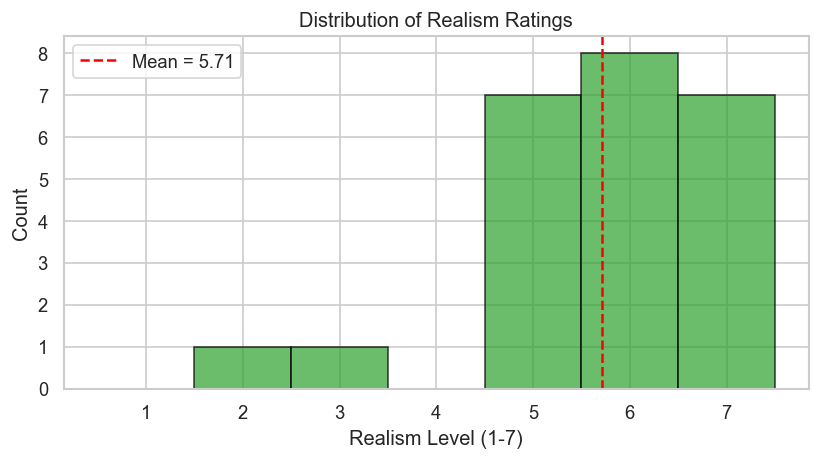


--- Realism by Scenario Factors ---

age_band: H=2.26, p=0.5200
  9-12: mean=6.33
  13-15: mean=5.57
  16-18: mean=5.60
  6-8: mean=5.33

domain: H=0.19, p=0.9086
  Casual Knowledge Domain: mean=5.62
  Academic Domain: mean=6.00
  Relationship Domain: mean=5.75

sensitivity_level: H=0.33, p=0.8488
  available: mean=5.60
  intimate: mean=5.50
  sensitive: mean=5.80

relationship_frame: H=0.07, p=0.7859
  tool: mean=5.92
  companion: mean=5.50

space_type: H=0.77, p=0.3798
  shared_family_space: mean=5.54
  private_space: mean=5.91

breakdown_expected: H=0.08, p=0.7768
  no: mean=5.70
  yes: mean=5.75

trait: H=2.69, p=0.6110
  Agreeableness: mean=6.50
  Conscientiousness: mean=6.00
  Extraversion: mean=6.00
  Neuroticism: mean=5.57
  Openness: mean=4.75

trait_level: H=0.00, p=0.9745
  low: mean=5.88
  high: mean=5.62

gender_identity: H=0.24, p=0.8867
  boy: mean=6.00
  girl: mean=5.54
  nonbinary: mean=5.75

Summary:


,Factor,H,p,Significant
0,age_band,2.261401,0.519956,
1,domain,0.191723,0.908590,
2,sensitivity_level,0.327947,0.848765,
3,relationship_frame,0.073788,0.785899,
4,space_type,0.771478,0.379760,
5,breakdown_expected,0.080347,0.776828,
6,trait,2.689554,0.611044,
7,trait_level,0.001025,0.974462,
8,gender_identity,0.240599,0.886655,


In [23]:
# ── Cell 5a: Realism Descriptives ────────────────────────────────────────────

realism = df_session['realism_level'].dropna()
print('=== Realism Descriptives ===')
print(f'N: {len(realism)}')
print(f'Mean: {realism.mean():.2f}, Median: {realism.median():.1f}, SD: {realism.std():.2f}')
print(f'Range: [{realism.min()}, {realism.max()}]')
print(f'Proportion \u22654 (neutral or above): {(realism >= 4).mean():.1%}')
print(f'Proportion \u22643 (below neutral): {(realism <= 3).mean():.1%}')

# Histogram
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(realism, bins=np.arange(0.5, 8.5, 1), edgecolor='black', alpha=0.7, color='#2ca02c')
ax.axvline(realism.mean(), color='red', linestyle='--', label=f'Mean = {realism.mean():.2f}')
ax.set_xlabel('Realism Level (1-7)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Realism Ratings')
ax.set_xticks(range(1, 8))
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'realism_histogram.png'), bbox_inches='tight')
plt.show()

# Realism by scenario factors
print('\n--- Realism by Scenario Factors ---')
realism_kw = []
for f in usable_factors:
    if f in df_session.columns:
        groups = [g['realism_level'].dropna().values
                  for _, g in df_session.groupby(f)
                  if len(g['realism_level'].dropna()) >= 1]
        if len(groups) >= 2:
            H, p = kruskal(*groups)
            realism_kw.append({'Factor': f, 'H': H, 'p': p,
                               'Significant': '*' if p < ALPHA else ''})
            means = df_session.groupby(f)['realism_level'].mean()
            print(f'\n{f}: H={H:.2f}, p={p:.4f}')
            for level, mean_r in means.items():
                print(f'  {level}: mean={mean_r:.2f}')

if realism_kw:
    print('\nSummary:')
    display(pd.DataFrame(realism_kw))

In [24]:
# ── Cell 5b: Realism as Moderator ────────────────────────────────────────────

print('=== Realism as Moderator of Concern ===')

realism_model_df = df_session.dropna(subset=['concern_level', 'realism_level']).copy()

if len(realism_model_df) >= 10:
    # Main effect of realism on concern
    formula_real = 'concern_level ~ realism_centered'
    r_real = fit_mixed_or_fallback(formula_real, realism_model_df, 'user_id')

    if r_real['converged']:
        print('\nRealism \u2192 Concern (main effect):')
        print(r_real['summary'])
        coef_realism = r_real['model'].params.get('realism_centered', np.nan)
        p_realism = r_real['model'].pvalues.get('realism_centered', np.nan)
        print(f'\nRealism coefficient: {coef_realism:.3f}, p = {p_realism:.4f}')
        if p_realism >= ALPHA:
            print('\u2192 Realism does NOT significantly predict concern level.')

    # Add realism interactions with scenario factors
    realism_int_terms = [f'C({f})' for f in usable_factors if f in realism_model_df.columns]
    if realism_int_terms:
        formula_real_int = ('concern_level ~ realism_centered + ' +
                            ' + '.join(realism_int_terms) + ' + ' +
                            ' + '.join(f'realism_centered:C({f})' for f in usable_factors
                                       if f in realism_model_df.columns))
        r_real_int = fit_mixed_or_fallback(formula_real_int, realism_model_df, 'user_id')
        if r_real_int['converged']:
            # Report realism interaction terms
            int_terms = r_real_int['model'].pvalues[
                r_real_int['model'].pvalues.index.str.contains('realism_centered:')
            ]
            n_sig_int = (int_terms < ALPHA).sum()
            print(f'\nRealism x factor interactions: {n_sig_int}/{len(int_terms)} significant')
            if n_sig_int == 0:
                print('\u2192 Realism does not moderate how parents respond to chatbot behavior.')
            else:
                print('Significant realism interactions:')
                display(int_terms[int_terms < ALPHA])
else:
    print('\u26a0 Insufficient data for realism moderation analysis.')

=== Realism as Moderator of Concern ===

Realism → Concern (main effect):
           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: concern_level
No. Observations: 24      Method:             REML         
No. Groups:       6       Scale:              3.4168       
Min. group size:  4       Log-Likelihood:     -49.7561     
Max. group size:  4       Converged:          Yes          
Mean group size:  4.0                                      
-----------------------------------------------------------
                   Coef. Std.Err.   z   P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept          4.833    0.542 8.919 0.000  3.771  5.895
realism_centered   0.396    0.426 0.929 0.353 -0.439  1.231
Group Var          0.908    0.801                          


Realism coefficient: 0.396, p = 0.3530
→ Realism does NOT significantly predict concern level.
Mixed model failed: Singular matrix
Falling back to OLS with

/opt/homebrew/Caskroom/miniforge/base/envs/open-webui/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2325: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/homebrew/Caskroom/miniforge/base/envs/open-webui/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2325: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/homebrew/Caskroom/miniforge/base/envs/open-webui/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2325: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/homebrew/Caskroom/miniforge/base/envs/open-webui/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1561: RuntimeWarning: invalid value encountered in log
  np.log(self.n_totobs - self.k_fe) / 2.)
/opt/homebrew/Caskroom/miniforge/base/envs/open-webui/lib/python3.11/site-packages/numpy/lin

In [25]:
# ── Cell 5c: TOST Equivalence Test ───────────────────────────────────────────

print('=== TOST Equivalence Test: Realism Effect on Concern ===')
print(f'Equivalence bound: \u00b1{EQUIVALENCE_BOUND} on 7-point scale')

if len(realism_model_df) >= 10:
    # Compute the correlation/regression coefficient between realism and concern
    from scipy.stats import pearsonr

    r_corr, p_corr = pearsonr(
        realism_model_df['realism_level'],
        realism_model_df['concern_level']
    )
    print(f'\nPearson r(realism, concern) = {r_corr:.3f}, p = {p_corr:.4f}')

    # TOST on the regression slope
    # H1: effect > -bound  AND  H2: effect < +bound
    if r_real.get('converged') and 'realism_centered' in r_real['model'].params:
        coef = r_real['model'].params['realism_centered']
        se = r_real['model'].bse['realism_centered']
        n = len(realism_model_df)

        # Two one-sided tests
        t_lower = (coef - (-EQUIVALENCE_BOUND)) / se
        t_upper = (coef - EQUIVALENCE_BOUND) / se
        from scipy.stats import t as t_dist
        df_tost = n - 2
        p_lower = t_dist.sf(t_lower, df_tost)   # P(effect > -bound)
        p_upper = t_dist.cdf(t_upper, df_tost)   # P(effect < +bound)

        print(f'\nTOST results:')
        print(f'  Coefficient: {coef:.4f} (SE = {se:.4f})')
        print(f'  Test 1 (effect > -{EQUIVALENCE_BOUND}): t = {t_lower:.2f}, p = {p_lower:.4f}')
        print(f'  Test 2 (effect < +{EQUIVALENCE_BOUND}): t = {t_upper:.2f}, p = {p_upper:.4f}')

        if p_lower < ALPHA and p_upper < ALPHA:
            print(f'  \u2714 EQUIVALENCE ESTABLISHED: Realism has a negligibly small effect on concern.')
            print(f'      The effect ({coef:.3f}) is within \u00b1{EQUIVALENCE_BOUND} of zero.')
        elif p_lower < ALPHA:
            print(f'  \u26a0 Partial: Effect is significantly > -{EQUIVALENCE_BOUND} but may be > +{EQUIVALENCE_BOUND}.')
        elif p_upper < ALPHA:
            print(f'  \u26a0 Partial: Effect is significantly < +{EQUIVALENCE_BOUND} but may be < -{EQUIVALENCE_BOUND}.')
        else:
            print(f'  \u2716 Equivalence NOT established. Cannot rule out a meaningful realism effect.')
    else:
        print('Realism model not available for TOST.')
else:
    print('\u26a0 Insufficient data for TOST.')

=== TOST Equivalence Test: Realism Effect on Concern ===
Equivalence bound: ±0.5 on 7-point scale

Pearson r(realism, concern) = 0.353, p = 0.0904

TOST results:
  Coefficient: 0.3957 (SE = 0.4261)
  Test 1 (effect > -0.5): t = 2.10, p = 0.0236
  Test 2 (effect < +0.5): t = -0.24, p = 0.4044
  ⚠ Partial: Effect is significantly > -0.5 but may be > +0.5.


In [26]:
# ── Cell 5d: Annotation Quality by Realism ──────────────────────────────────

print('=== Annotation Quality by Realism Group ===')

if len(df_session) >= 10:
    # Mean realism per scenario
    scenario_realism = df_session.groupby('scenario_id')['realism_level'].mean()

    # Split: high (>= 5) vs low (<= 3)
    high_realism_scenarios = set(scenario_realism[scenario_realism >= 5].index)
    low_realism_scenarios = set(scenario_realism[scenario_realism <= 3].index)

    if len(low_realism_scenarios) < 3:
        print(f'Too few low-realism scenarios ({len(low_realism_scenarios)}). Using median split instead.')
        median_realism = scenario_realism.median()
        high_realism_scenarios = set(scenario_realism[scenario_realism >= median_realism].index)
        low_realism_scenarios = set(scenario_realism[scenario_realism < median_realism].index)
        print(f'Median realism: {median_realism:.2f}')

    print(f'High-realism scenarios: {len(high_realism_scenarios)}')
    print(f'Low-realism scenarios: {len(low_realism_scenarios)}')

    df_high = df_session[df_session['scenario_id'].isin(high_realism_scenarios)]
    df_low = df_session[df_session['scenario_id'].isin(low_realism_scenarios)]

    comparisons = []

    # 1. Highlights per session
    if 'n_highlights' in df_high.columns:
        hl_high = df_high['n_highlights'].values
        hl_low = df_low['n_highlights'].values
        if len(hl_high) > 0 and len(hl_low) > 0:
            U, p = mannwhitneyu(hl_high, hl_low, alternative='two-sided')
            d = (hl_high.mean() - hl_low.mean()) / np.sqrt((hl_high.std()**2 + hl_low.std()**2) / 2) if (hl_high.std() + hl_low.std()) > 0 else 0
            comparisons.append({
                'Metric': 'Highlights per session',
                'High Realism (mean)': f'{hl_high.mean():.2f}',
                'Low Realism (mean)': f'{hl_low.mean():.2f}',
                'U': U, 'p': p, "Cohen's d": f'{d:.2f}'
            })

    # 2. Rationale length
    if 'concern_reason' in df_high.columns:
        len_high = df_high['concern_reason'].dropna().str.len().values
        len_low = df_low['concern_reason'].dropna().str.len().values
        if len(len_high) > 0 and len(len_low) > 0:
            U, p = mannwhitneyu(len_high, len_low, alternative='two-sided')
            d = (len_high.mean() - len_low.mean()) / np.sqrt((len_high.std()**2 + len_low.std()**2) / 2) if (len_high.std() + len_low.std()) > 0 else 0
            comparisons.append({
                'Metric': 'Rationale length (chars)',
                'High Realism (mean)': f'{len_high.mean():.1f}',
                'Low Realism (mean)': f'{len_low.mean():.1f}',
                'U': U, 'p': p, "Cohen's d": f'{d:.2f}'
            })

    # 3. Concern variance per scenario
    var_high = df_high.groupby('scenario_id')['concern_level'].var().dropna().values
    var_low = df_low.groupby('scenario_id')['concern_level'].var().dropna().values
    if len(var_high) > 0 and len(var_low) > 0:
        U, p = mannwhitneyu(var_high, var_low, alternative='two-sided')
        d = (var_high.mean() - var_low.mean()) / np.sqrt((var_high.std()**2 + var_low.std()**2) / 2) if (var_high.std() + var_low.std()) > 0 else 0
        comparisons.append({
            'Metric': 'Concern variance (per scenario)',
            'High Realism (mean)': f'{var_high.mean():.2f}',
            'Low Realism (mean)': f'{var_low.mean():.2f}',
            'U': U, 'p': p, "Cohen's d": f'{d:.2f}'
        })

    if comparisons:
        comp_df = pd.DataFrame(comparisons)
        display(comp_df)
    else:
        print('No comparisons could be computed.')
else:
    print('\u26a0 Insufficient data for realism-based quality comparison.')

=== Annotation Quality by Realism Group ===
Too few low-realism scenarios (2). Using median split instead.
Median realism: 6.00
High-realism scenarios: 13
Low-realism scenarios: 8


,Metric,High Realism (mean),Low Realism (mean),U,p,Cohen's d
0,Highlights per session,1.93,1.67,76.5,0.567553,0.26
1,Rationale length (chars),320.5,569.7,58.5,0.612111,-0.60
2,Concern variance (per scenario),4.00,4.50,1.0,1.000000,-0.18


---
## Output: Export All Results

In [ ]:
# ── Export All Results ────────────────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Exporting results to: {OUTPUT_DIR}')

# ── Tables ──

# 1. Model comparison table
model_comp_rows = []
for name, key in [('Null', 'null'), ('Main Effects', 'main'), ('Interactions', 'interaction')]:
    r = model_results.get(key, {})
    if isinstance(r, dict) and r.get('converged'):
        m = r['model']
        row = {'Model': name, 'Type': r.get('model_type', 'unknown')}
        row['AIC'] = getattr(m, 'aic', np.nan)
        row['BIC'] = getattr(m, 'bic', np.nan)
        row['Log-Likelihood'] = getattr(m, 'llf', np.nan)
        row['N_params'] = getattr(m, 'df_modelwc', getattr(m, 'k_params', np.nan))
        model_comp_rows.append(row)
if model_comp_rows:
    mc_df = pd.DataFrame(model_comp_rows)
    mc_df.to_csv(os.path.join(OUTPUT_DIR, 'model_comparison_table.csv'), index=False)
    print('  model_comparison_table.csv')

# 2. Significant interactions
if not effects_df.empty:
    sig_eff = effects_df[effects_df['significant']].copy()
    sig_eff['term'] = sig_eff.index
    sig_eff.to_csv(os.path.join(OUTPUT_DIR, 'significant_interactions.csv'), index=False)
    print('  significant_interactions.csv')

# 3. Marginal effects (group means by factor combinations)
marginal_rows = []
for f in usable_factors:
    if f in model_df.columns:
        grp = model_df.groupby(f)['concern_level'].agg(['mean', 'std', 'count']).reset_index()
        grp['factor'] = f
        grp.columns = ['level', 'mean_concern', 'sd_concern', 'n', 'factor']
        marginal_rows.append(grp)
if marginal_rows:
    mg_df = pd.concat(marginal_rows, ignore_index=True)
    mg_df.to_csv(os.path.join(OUTPUT_DIR, 'marginal_effects.csv'), index=False)
    print('  marginal_effects.csv')

# 7. Realism invariance
realism_rows = []
if r_real.get('converged') and 'realism_centered' in r_real['model'].params:
    realism_rows.append({
        'term': 'realism_centered',
        'coef': r_real['model'].params['realism_centered'],
        'se': r_real['model'].bse['realism_centered'],
        'p': r_real['model'].pvalues['realism_centered'],
    })
if realism_rows:
    real_df = pd.DataFrame(realism_rows)
    real_df.to_csv(os.path.join(OUTPUT_DIR, 'realism_invariance.csv'), index=False)
    print('  realism_invariance.csv')

# ── Summary Report ──
summary_lines = [
    'CONTEXTUAL ANALYSIS SUMMARY',
    '=' * 50,
    f'Date: {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")}',
    f'Data: {EXPORT_TIMESTAMP}',
    f'Sessions: {len(df_session)}, Parents: {n_parents}, Scenarios: {n_scenarios}',
    f'Highlights: {len(df_highlight) if not df_highlight.empty else 0}',
    f'Model strategy: {strategy}',
    '',
    '--- Key Findings ---',
]

# LRT result
if 'interaction' in model_results and model_results['interaction'].get('converged'):
    summary_lines.append('LRT (interactions vs main effects): See model_comparison_table.csv')
else:
    summary_lines.append('LRT: Not computed (insufficient data or model did not converge).')

# Most influential effects
if not effects_df.empty:
    top = effects_df.nlargest(3, 'abs_std_coef')
    summary_lines.append(f'\nTop 3 effects by size: {list(top.index)}')

# Concern codes
if HAS_CONCERN_CODES:
    summary_lines.append('\nConcern type analysis: Completed (see concern_type_by_context.csv)')
else:
    summary_lines.append('\nConcern type analysis: SKIPPED (codes not yet available)')

# LLM coding
if HAS_BOTH_CODES:
    summary_lines.append('LLM coding comparison: Completed (see llm_coding_agreement.csv)')
else:
    summary_lines.append('LLM coding comparison: SKIPPED (codes not yet available)')

# Realism
if r_real.get('converged') and 'realism_centered' in r_real['model'].pvalues:
    p_r = r_real['model'].pvalues['realism_centered']
    if p_r >= ALPHA:
        summary_lines.append(f'\nRealism invariance: Realism does NOT predict concern (p={p_r:.4f}). Good.')
    else:
        summary_lines.append(f'\nRealism invariance: Realism IS a significant predictor (p={p_r:.4f}). Caveat needed.')
else:
    summary_lines.append('\nRealism invariance: Not tested.')

summary_text = '\n'.join(summary_lines)
with open(os.path.join(OUTPUT_DIR, 'analysis_summary.txt'), 'w') as f:
    f.write(summary_text)
print('  analysis_summary.txt')

print(f'\n{"=" * 50}')
print(summary_text)
print(f'\nAll outputs saved to: {OUTPUT_DIR}')